In [1]:
# ====================================================================================================
# GPU / PYTORCH DIAGNOSTIC
# ====================================================================================================

import sys
import torch

print("=" * 100)
print("PYTORCH / CUDA DIAGNOSTIC")
print("=" * 100)

print(f"Python executable : {sys.executable}")
print(f"PyTorch version   : {torch.__version__}")
print(f"PyTorch CUDA      : {torch.version.cuda}")
print(f"CUDA available    : {torch.cuda.is_available()}")
print(f"CUDA device count : {torch.cuda.device_count()}")

if torch.cuda.is_available():
    print(f"GPU               : {torch.cuda.get_device_name(0)}")
    print(f"Capability        : {torch.cuda.get_device_capability(0)}")
    print(f"Current device    : {torch.cuda.current_device()}")

print("=" * 100)

PYTORCH / CUDA DIAGNOSTIC
Python executable : c:\Users\User\AppData\Local\Programs\Python\Python311\python.exe
PyTorch version   : 2.13.0+cu126
PyTorch CUDA      : 12.6
CUDA available    : True
CUDA device count : 1
GPU               : NVIDIA GeForce RTX 4050 Laptop GPU
Capability        : (8, 9)
Current device    : 0


In [2]:
# ====================================================================================================
# PHASE 8 — CELL 1
# CONFIGURATION & ENVIRONMENT
# ====================================================================================================

from pathlib import Path
import os
import sys
import json
import time
import random
import unicodedata

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ----------------------------------------------------------------------------------------------------
# PROJECT CONFIG
# ----------------------------------------------------------------------------------------------------

PROJECT_ROOT = Path(r"C:\LipReadingSSL")

PHASE7_DIR = PROJECT_ROOT / "output" / "phase7_dataset"

MASTER_MANIFEST = PHASE7_DIR / "dataset_manifest.csv"
TRAIN_MANIFEST = PHASE7_DIR / "train_manifest.csv"
VAL_MANIFEST = PHASE7_DIR / "validation_manifest.csv"
TEST_MANIFEST = PHASE7_DIR / "test_manifest.csv"

PHASE8_DIR = PROJECT_ROOT / "output" / "phase8_lipreading"

CHECKPOINT_DIR = PHASE8_DIR / "checkpoints"
LOG_DIR = PHASE8_DIR / "logs"
RESULT_DIR = PHASE8_DIR / "results"

for directory in [
    PHASE8_DIR,
    CHECKPOINT_DIR,
    LOG_DIR,
    RESULT_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

# ----------------------------------------------------------------------------------------------------
# TRAINING CONFIG
# ----------------------------------------------------------------------------------------------------

SEED = 42

IMAGE_SIZE = 96

# We DO NOT force every sequence to 15 frames.
# The dataset may contain variable-length sequences.
MIN_FRAMES = 5
MAX_FRAMES = 150

BATCH_SIZE = 4
NUM_WORKERS = 0

EPOCHS = 100

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

GRAD_CLIP = 5.0

USE_AMP = True

# ----------------------------------------------------------------------------------------------------
# CTC CONFIG
# ----------------------------------------------------------------------------------------------------

BLANK_TOKEN = "<blank>"
UNK_TOKEN = "<unk>"

# ----------------------------------------------------------------------------------------------------
# DEVICE
# ----------------------------------------------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

AMP_ENABLED = (
    USE_AMP and
    DEVICE.type == "cuda"
)

# ----------------------------------------------------------------------------------------------------
# REPRODUCIBILITY
# ----------------------------------------------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ----------------------------------------------------------------------------------------------------
# HEADER
# ----------------------------------------------------------------------------------------------------

print("=" * 100)
print("PHASE 8 — LIP READING MODEL")
print("=" * 100)

print()
print("PROJECT")
print("-" * 100)
print(f"Project root       : {PROJECT_ROOT}")
print(f"Phase 7 directory  : {PHASE7_DIR}")
print(f"Phase 8 directory  : {PHASE8_DIR}")

print()
print("MODEL STRATEGY")
print("-" * 100)
print("Task               : Thai Visual Speech Recognition")
print("Label level        : Character")
print("Decoder            : CTC")
print("Temporal model     : BiLSTM")
print("Sequence mode      : VARIABLE LENGTH")
print(f"Image size         : {IMAGE_SIZE} x {IMAGE_SIZE}")

print()
print("TRAINING")
print("-" * 100)
print(f"Batch size         : {BATCH_SIZE}")
print(f"Epochs             : {EPOCHS}")
print(f"Learning rate      : {LEARNING_RATE}")
print(f"Weight decay       : {WEIGHT_DECAY}")
print(f"Seed               : {SEED}")
print(f"Workers            : {NUM_WORKERS}")

print()
print("DEVICE")
print("-" * 100)
print(f"Device             : {DEVICE}")
print(f"CUDA available     : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU                : {torch.cuda.get_device_name(0)}")
    print(f"CUDA capability    : {torch.cuda.get_device_capability(0)}")

print()
print(f"AMP enabled        : {AMP_ENABLED}")

# ----------------------------------------------------------------------------------------------------
# REQUIRED FILE CHECK
# ----------------------------------------------------------------------------------------------------

required_files = [
    MASTER_MANIFEST,
    TRAIN_MANIFEST,
    VAL_MANIFEST,
    TEST_MANIFEST,
]

missing = [
    str(path)
    for path in required_files
    if not path.exists()
]

if missing:
    raise FileNotFoundError(
        "Missing Phase 7 manifest files:\n" +
        "\n".join(missing)
    )

print()
print("Phase 7 manifests : ALL FOUND")

print()
print("✅ PHASE 8 CELL 1 READY")

PHASE 8 — LIP READING MODEL

PROJECT
----------------------------------------------------------------------------------------------------
Project root       : C:\LipReadingSSL
Phase 7 directory  : C:\LipReadingSSL\output\phase7_dataset
Phase 8 directory  : C:\LipReadingSSL\output\phase8_lipreading

MODEL STRATEGY
----------------------------------------------------------------------------------------------------
Task               : Thai Visual Speech Recognition
Label level        : Character
Decoder            : CTC
Temporal model     : BiLSTM
Sequence mode      : VARIABLE LENGTH
Image size         : 96 x 96

TRAINING
----------------------------------------------------------------------------------------------------
Batch size         : 4
Epochs             : 100
Learning rate      : 0.0001
Weight decay       : 0.0001
Seed               : 42
Workers            : 0

DEVICE
----------------------------------------------------------------------------------------------------
Device     

In [3]:
# ====================================================================================================
# PHASE 8 — CELL 2
# LOAD & VALIDATE DATASET MANIFESTS
# ====================================================================================================

print("=" * 100)
print("PHASE 8 — CELL 2 — DATASET MANIFEST VALIDATION")
print("=" * 100)

REQUIRED_COLUMNS = [
    "video",
    "clip_id",
    "start_frame",
    "end_frame",
    "fps",
    "start_time",
    "end_time",
    "duration_sec",
    "audio_start_sample",
    "audio_end_sample",
    "audio_path",
    "audio_storage_mode",
    "transcript",
    "status",
    "error",
    "split",
]

def load_manifest(path, name):
    print()
    print(f"Loading {name}")
    print("-" * 100)

    df = pd.read_csv(
        path,
        low_memory=False
    )

    print(f"Rows    : {len(df):,}")
    print(f"Columns : {len(df.columns):,}")

    missing = [
        col
        for col in REQUIRED_COLUMNS
        if col not in df.columns
    ]

    if missing:
        raise ValueError(
            f"{name} missing columns: {missing}"
        )

    return df


train_df = load_manifest(
    TRAIN_MANIFEST,
    "TRAIN"
)

val_df = load_manifest(
    VAL_MANIFEST,
    "VALIDATION"
)

test_df = load_manifest(
    TEST_MANIFEST,
    "TEST"
)

# ----------------------------------------------------------------------------------------------------
# NORMALIZATION
# ----------------------------------------------------------------------------------------------------

for df in [
    train_df,
    val_df,
    test_df,
]:

    df["video"] = (
        df["video"]
        .astype(str)
        .str.strip()
    )

    df["clip_id"] = pd.to_numeric(
        df["clip_id"],
        errors="coerce"
    )

    numeric_columns = [
        "start_frame",
        "end_frame",
        "fps",
        "start_time",
        "end_time",
        "duration_sec",
        "audio_start_sample",
        "audio_end_sample",
    ]

    for col in numeric_columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    df["transcript"] = (
        df["transcript"]
        .fillna("")
        .astype(str)
        .map(
            lambda x:
            unicodedata.normalize(
                "NFC",
                x.strip()
            )
        )
    )

    df["split"] = (
        df["split"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
    )

# ----------------------------------------------------------------------------------------------------
# VALIDATION
# ----------------------------------------------------------------------------------------------------

all_df = pd.concat(
    [
        train_df,
        val_df,
        test_df,
    ],
    ignore_index=True
)

print()
print("=" * 100)
print("DATASET VALIDATION")
print("=" * 100)

print(f"Total clips       : {len(all_df):,}")
print(f"Train             : {len(train_df):,}")
print(f"Validation        : {len(val_df):,}")
print(f"Test              : {len(test_df):,}")

empty_labels = int(
    all_df["transcript"]
    .eq("")
    .sum()
)

duplicate_keys = int(
    all_df
    .duplicated(
        subset=["video", "clip_id"],
        keep=False
    )
    .sum()
)

invalid_frames = int(
    (
        (all_df["start_frame"] < 0) |
        (all_df["end_frame"] <= all_df["start_frame"])
    )
    .sum()
)

invalid_fps = int(
    (
        all_df["fps"] <= 0
    ).sum()
)

print()
print(f"Empty labels      : {empty_labels:,}")
print(f"Duplicate keys    : {duplicate_keys:,}")
print(f"Invalid frames    : {invalid_frames:,}")
print(f"Invalid FPS       : {invalid_fps:,}")

if empty_labels:
    raise ValueError(
        "Empty transcript labels detected."
    )

if duplicate_keys:
    raise ValueError(
        "Duplicate video + clip_id detected."
    )

if invalid_frames:
    raise ValueError(
        "Invalid frame ranges detected."
    )

if invalid_fps:
    raise ValueError(
        "Invalid FPS detected."
    )

# ----------------------------------------------------------------------------------------------------
# SPLIT VALIDATION
# ----------------------------------------------------------------------------------------------------

if not set(train_df["split"]) <= {"train"}:
    raise ValueError(
        "Train manifest contains invalid split values."
    )

if not set(val_df["split"]) <= {"validation"}:
    raise ValueError(
        "Validation manifest contains invalid split values."
    )

if not set(test_df["split"]) <= {"test"}:
    raise ValueError(
        "Test manifest contains invalid split values."
    )

print()
print("Split validation : PASS")
print("Input validation : PASS")

print()
print("✅ PHASE 8 CELL 2 READY")

PHASE 8 — CELL 2 — DATASET MANIFEST VALIDATION

Loading TRAIN
----------------------------------------------------------------------------------------------------
Rows    : 76,538
Columns : 19

Loading VALIDATION
----------------------------------------------------------------------------------------------------
Rows    : 9,566
Columns : 19

Loading TEST
----------------------------------------------------------------------------------------------------
Rows    : 9,570
Columns : 19

DATASET VALIDATION
Total clips       : 95,674
Train             : 76,538
Validation        : 9,566
Test              : 9,570

Empty labels      : 0
Duplicate keys    : 0
Invalid frames    : 0
Invalid FPS       : 0

Split validation : PASS
Input validation : PASS

✅ PHASE 8 CELL 2 READY


In [4]:
# ====================================================================================================
# PHASE 8 — CELL 3
# THAI CHARACTER VOCABULARY
# ====================================================================================================

print("=" * 100)
print("PHASE 8 — CELL 3 — THAI CHARACTER VOCABULARY")
print("=" * 100)

# ----------------------------------------------------------------------------------------------------
# TEXT NORMALIZATION
# ----------------------------------------------------------------------------------------------------

def normalize_text(text):
    if text is None:
        return ""

    text = str(text)

    text = unicodedata.normalize(
        "NFC",
        text
    )

    text = " ".join(
        text.strip().split()
    )

    return text


# ----------------------------------------------------------------------------------------------------
# BUILD VOCABULARY FROM TRAIN ONLY
# ----------------------------------------------------------------------------------------------------

train_texts = (
    train_df["transcript"]
    .map(normalize_text)
    .tolist()
)

characters = set()

for text in train_texts:
    characters.update(text)

characters = sorted(
    characters
)

# blank = 0
# unk   = 1

itos = [
    BLANK_TOKEN,
    UNK_TOKEN,
]

itos.extend(
    characters
)

stoi = {
    token: index
    for index, token in enumerate(itos)
}

NUM_CLASSES = len(itos)

# ----------------------------------------------------------------------------------------------------
# ENCODE / DECODE
# ----------------------------------------------------------------------------------------------------

def encode_text(text):
    text = normalize_text(text)

    return [
        stoi.get(
            char,
            stoi[UNK_TOKEN]
        )
        for char in text
    ]


def decode_tokens(tokens):
    result = []

    for token in tokens:

        token = int(token)

        if token == stoi[BLANK_TOKEN]:
            continue

        if token == stoi[UNK_TOKEN]:
            continue

        if 0 <= token < len(itos):
            result.append(
                itos[token]
            )

    return "".join(result)


# ----------------------------------------------------------------------------------------------------
# STATISTICS
# ----------------------------------------------------------------------------------------------------

train_lengths = [
    len(encode_text(text))
    for text in train_texts
]

print()
print(f"Training transcripts : {len(train_texts):,}")
print(f"Vocabulary size      : {NUM_CLASSES:,}")
print(f"Character classes    : {NUM_CLASSES - 2:,}")

if train_lengths:
    print()
    print(
        f"Label length min     : {min(train_lengths)}"
    )

    print(
        f"Label length mean    : {np.mean(train_lengths):.2f}"
    )

    print(
        f"Label length median  : {np.median(train_lengths):.2f}"
    )

    print(
        f"Label length max     : {max(train_lengths)}"
    )

# ----------------------------------------------------------------------------------------------------
# SAVE VOCAB
# ----------------------------------------------------------------------------------------------------

VOCAB_FILE = PHASE8_DIR / "thai_vocab.json"

with open(
    VOCAB_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        {
            "blank_token": BLANK_TOKEN,
            "unk_token": UNK_TOKEN,
            "itos": itos,
            "stoi": stoi,
        },
        f,
        ensure_ascii=False,
        indent=2
    )

print()
print(f"Vocabulary saved : {VOCAB_FILE}")

# ----------------------------------------------------------------------------------------------------
# TEST
# ----------------------------------------------------------------------------------------------------

sample_text = train_texts[0]

encoded = encode_text(
    sample_text
)

decoded = decode_tokens(
    encoded
)

print()
print("VOCABULARY TEST")
print("-" * 100)
print(f"Original : {sample_text}")
print(f"Encoded  : {encoded[:30]}")
print(f"Decoded  : {decoded}")

if decoded != sample_text:
    raise ValueError(
        "Vocabulary encode/decode test failed."
    )

print()
print("Vocabulary test : PASS")
print()
print("✅ PHASE 8 CELL 3 READY")

PHASE 8 — CELL 3 — THAI CHARACTER VOCABULARY

Training transcripts : 76,538
Vocabulary size      : 67
Character classes    : 65

Label length min     : 1
Label length mean    : 9.15
Label length median  : 9.00
Label length max     : 26

Vocabulary saved : C:\LipReadingSSL\output\phase8_lipreading\thai_vocab.json

VOCABULARY TEST
----------------------------------------------------------------------------------------------------
Original : ผล ต้อน แท้น นั
Encoded  : [27, 36, 2, 20, 63, 43, 24, 2, 56, 22, 63, 24, 2, 24, 46]
Decoded  : ผล ต้อน แท้น นั

Vocabulary test : PASS

✅ PHASE 8 CELL 3 READY


In [5]:
# ==================================================================================================
# PHASE 8 — CELL 4 — MOUTH FRAME RESOLUTION / AVAILABILITY QA
# ==================================================================================================
#
# PURPOSE
# -------
# Resolve existing Phase 5 mouth-frame storage without creating/copying files.
#
# IMPORTANT
# ---------
# - Do NOT create mouth frames
# - Do NOT copy mouth frames
# - Do NOT create WAV files
# - Do NOT load audio
# - Do NOT recursively scan C:\LipReadingSSL\output
# - Use Phase 5 mouth_metadata.csv as the primary source of truth
# - Check only a small number of representative frame files
#
# Phase 5 structure confirmed from project:
#
#   C:\LipReadingSSL\output\video001\
#       mouth_metadata.csv
#       <mouth crop directory>
#
#   C:\LipReadingSSL\output\video002\
#       mouth_metadata.csv
#       <mouth crop directory>
#
#   C:\LipReadingSSL\output\video003\
#       mouth_metadata.csv
#       <mouth crop directory>
#
# ==================================================================================================

from pathlib import Path
import pandas as pd
import re
import json
import time


# ==================================================================================================
# CONFIGURATION
# ==================================================================================================

PROJECT_ROOT = Path(r"C:\LipReadingSSL")

PHASE6G_METADATA = (
    PROJECT_ROOT
    / "output"
    / "phase6_audio"
    / "phase6G"
    / "dataset_metadata.csv"
)

PHASE7_OUTPUT = (
    PROJECT_ROOT
    / "output"
    / "phase7_dataset"
)

QA_OUTPUT = (
    PHASE7_OUTPUT
    / "mouth_frame_resolution_qa.csv"
)

QA_SUMMARY_OUTPUT = (
    PHASE7_OUTPUT
    / "mouth_frame_resolution_qa_summary.json"
)

VIDEOS = [
    "video001",
    "video002",
    "video003",
]

VIDEO_OUTPUT_ROOT = (
    PROJECT_ROOT
    / "output"
)

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
}

# Only inspect a few files per video.
# This prevents 
# from becoming a massive filesystem scan.
SAMPLE_LIMIT = 5


# ==================================================================================================
# DISPLAY HELPERS
# ==================================================================================================

def section(title):
    print()
    print("=" * 100)
    print(title)
    print("=" * 100)


def subsection(title):
    print()
    print("-" * 100)
    print(title)
    print("-" * 100)


def extract_frame_index(value):
    """
    Extract a frame number from a filename/path.

    Examples:
        frame_000123.jpg -> 123
        mouth_123.jpg    -> 123
        123.jpg          -> 123
    """

    if value is None:
        return None

    text = str(value)

    stem = Path(text).stem

    numbers = re.findall(r"\d+", stem)

    if not numbers:
        return None

    try:
        return int(numbers[-1])
    except Exception:
        return None


# ==================================================================================================
# START
# ==================================================================================================

start_time = time.time()

section(
    "PHASE 8 — CELL 4 — MOUTH FRAME RESOLUTION / AVAILABILITY QA"
)

print(f"Project root      : {PROJECT_ROOT}")
print(f"Phase 6G metadata : {PHASE6G_METADATA}")
print(f"QA output         : {QA_OUTPUT}")

subsection("STORAGE STRATEGY")

print("✓ No image files will be created")
print("✓ No image files will be copied")
print("✓ No WAV files will be created")
print("✓ No audio files will be loaded")
print("✓ No recursive scan of C:\\LipReadingSSL\\output")
print("✓ Phase 5 mouth_metadata.csv is the primary source")
print("✓ Only representative frame files are checked")


# ==================================================================================================
# 1. PRE-CHECK
# ==================================================================================================

subsection("1. PRE-CHECK")

if not PHASE6G_METADATA.exists():
    raise FileNotFoundError(
        f"Phase 6G metadata not found:\n{PHASE6G_METADATA}"
    )

PHASE7_OUTPUT.mkdir(
    parents=True,
    exist_ok=True
)

print("Phase 6G metadata : FOUND")
print(
    f"Metadata size     : "
    f"{PHASE6G_METADATA.stat().st_size / (1024 * 1024):.2f} MB"
)
print("Output directory  : READY")


# ==================================================================================================
# 2. LOAD PHASE 6G
# ==================================================================================================

subsection("2. LOADING PHASE 6G DATASET METADATA")

df = pd.read_csv(
    PHASE6G_METADATA
)

print(f"Rows              : {len(df):,}")
print(f"Columns           : {list(df.columns)}")


required_columns = [
    "video",
    "clip_id",
    "start_frame",
    "end_frame",
    "fps",
    "transcript",
]

missing_columns = [
    col
    for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Phase 6G metadata missing columns: {missing_columns}"
    )

print("Required columns  : ALL PRESENT")


# ==================================================================================================
# 3. BASIC INPUT VALIDATION
# ==================================================================================================

subsection("3. INPUT VALIDATION")

numeric_columns = [
    "start_frame",
    "end_frame",
    "fps",
]

for col in numeric_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

invalid_numeric = (
    df[numeric_columns]
    .isna()
    .any(axis=1)
)

invalid_frame_range = (
    (df["start_frame"] < 0)
    |
    (df["end_frame"] <= df["start_frame"])
)

invalid_fps = (
    df["fps"] <= 0
)

empty_transcript = (
    df["transcript"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
)

print(
    f"Invalid numeric rows : "
    f"{int(invalid_numeric.sum()):,}"
)

print(
    f"Invalid frame rows   : "
    f"{int(invalid_frame_range.sum()):,}"
)

print(
    f"Invalid FPS rows     : "
    f"{int(invalid_fps.sum()):,}"
)

print(
    f"Empty transcripts    : "
    f"{int(empty_transcript.sum()):,}"
)


# ==================================================================================================
# 4. PHASE 5 METADATA RESOLUTION
# ==================================================================================================

subsection(
    "4. RESOLVING EXISTING PHASE 5 MOUTH METADATA"
)

resolution_rows = []

for video in VIDEOS:

    video_dir = (
        VIDEO_OUTPUT_ROOT
        / video
    )

    mouth_metadata_path = (
        video_dir
        / "mouth_metadata.csv"
    )

    row = {
        "video": video,
        "video_output_dir": str(video_dir),
        "mouth_metadata": str(mouth_metadata_path),
        "video_dir_exists": video_dir.exists(),
        "mouth_metadata_exists": mouth_metadata_path.exists(),
        "metadata_rows": 0,
        "metadata_frame_ids": 0,
        "metadata_duplicate_frame_ids": 0,
        "metadata_has_frame_index": False,
        "candidate_mouth_dirs": "",
        "resolved_mouth_dir": "",
        "sample_files_found": 0,
        "sample_files_missing": 0,
        "status": "UNKNOWN",
        "error": "",
    }

    print()
    print(f"{video}")

    print(
        f"  Video directory : "
        f"{video_dir}"
    )

    if not video_dir.exists():

        print("  Video directory : NOT FOUND")

        row["status"] = "VIDEO_DIR_NOT_FOUND"
        row["error"] = "missing_video_output_directory"

        resolution_rows.append(row)

        continue

    print("  Video directory : FOUND")

    if not mouth_metadata_path.exists():

        print(
            "  mouth_metadata.csv : NOT FOUND"
        )

        row["status"] = "MOUTH_METADATA_NOT_FOUND"
        row["error"] = "missing_mouth_metadata"

        resolution_rows.append(row)

        continue

    print(
        "  mouth_metadata.csv : FOUND"
    )

    try:

        mouth_df = pd.read_csv(
            mouth_metadata_path
        )

    except Exception as e:

        row["status"] = "MOUTH_METADATA_READ_ERROR"
        row["error"] = (
            f"{type(e).__name__}: {e}"
        )

        resolution_rows.append(row)

        continue

    row["metadata_rows"] = len(mouth_df)

    print(
        f"  Metadata rows      : "
        f"{len(mouth_df):,}"
    )

    # ------------------------------------------------------------------
    # Resolve frame index column
    # ------------------------------------------------------------------

    frame_column = None

    for candidate in [
        "frame_index",
        "frame_id",
        "frame",
        "frame_number",
    ]:

        if candidate in mouth_df.columns:

            frame_column = candidate
            break

    if frame_column is None:

        print(
            "  Frame index column : NOT FOUND"
        )

        row["status"] = "NO_FRAME_INDEX"
        row["error"] = "missing_frame_index"

        resolution_rows.append(row)

        continue

    row["metadata_has_frame_index"] = True

    frame_series = pd.to_numeric(
        mouth_df[frame_column],
        errors="coerce"
    )

    valid_frame_ids = (
        frame_series
        .dropna()
        .astype(int)
    )

    row["metadata_frame_ids"] = (
        valid_frame_ids.nunique()
    )

    row["metadata_duplicate_frame_ids"] = int(
        valid_frame_ids.duplicated().sum()
    )

    print(
        f"  Frame index column : {frame_column}"
    )

    print(
        f"  Unique frame IDs   : "
        f"{row['metadata_frame_ids']:,}"
    )

    print(
        f"  Duplicate IDs      : "
        f"{row['metadata_duplicate_frame_ids']:,}"
    )


    # ------------------------------------------------------------------
    # Try to discover mouth directory WITHOUT recursive scanning
    # ------------------------------------------------------------------

    candidate_dirs = []

    # Most likely names first.
    preferred_names = [
        "mouth_crop",
        "mouth_crops",
        "mouth",
        "mouth_frames",
        "frames",
    ]

    for dirname in preferred_names:

        candidate = (
            video_dir
            / dirname
        )

        if candidate.is_dir():

            candidate_dirs.append(
                candidate
            )

    # Also inspect only direct child directories.
    # NO rglob.
    if not candidate_dirs:

        try:

            for child in video_dir.iterdir():

                if not child.is_dir():
                    continue

                name = child.name.lower()

                if "mouth" in name:

                    candidate_dirs.append(
                        child
                    )

        except Exception:
            pass

    row["candidate_mouth_dirs"] = ";".join(
        str(p)
        for p in candidate_dirs
    )

    if candidate_dirs:

        print("  Candidate mouth dirs:")

        for path in candidate_dirs[:5]:

            print(
                f"    - {path}"
            )

    else:

        print(
            "  Candidate mouth dirs : NONE"
        )


    # ------------------------------------------------------------------
    # Resolve actual frame directory
    # ------------------------------------------------------------------

    resolved_dir = None

    for candidate_dir in candidate_dirs:

        try:

            # Check only immediate children.
            # No recursive scan.
            found_image = False

            for child in candidate_dir.iterdir():

                if (
                    child.is_file()
                    and
                    child.suffix.lower()
                    in IMAGE_EXTENSIONS
                ):

                    found_image = True
                    break

            if found_image:

                resolved_dir = candidate_dir
                break

        except Exception:
            continue

    if resolved_dir is None:

        print(
            "  Mouth frame directory : NOT RESOLVED"
        )

        row["status"] = "METADATA_FOUND_FRAME_DIR_NOT_RESOLVED"
        row["error"] = "no_direct_image_files_found"

        resolution_rows.append(row)

        continue

    row["resolved_mouth_dir"] = str(
        resolved_dir
    )

    print(
        f"  Resolved mouth dir    : "
        f"{resolved_dir}"
    )


    # ==================================================================
    # 5. REPRESENTATIVE FRAME CHECK
    # ==================================================================

    sample_ids = (
        valid_frame_ids
        .drop_duplicates()
        .sort_values()
        .head(SAMPLE_LIMIT)
        .tolist()
    )

    print(
        f"  Checking sample IDs  : "
        f"{sample_ids}"
    )

    # Build a tiny direct filename index only from immediate directory.
    # This is intentionally NOT recursive.
    direct_files = []

    try:

        for child in resolved_dir.iterdir():

            if (
                child.is_file()
                and
                child.suffix.lower()
                in IMAGE_EXTENSIONS
            ):

                direct_files.append(child)

    except Exception as e:

        row["status"] = "FRAME_DIRECTORY_READ_ERROR"
        row["error"] = (
            f"{type(e).__name__}: {e}"
        )

        resolution_rows.append(row)

        continue


    # Map extracted frame IDs -> file
    frame_file_map = {}

    for path in direct_files:

        frame_id = extract_frame_index(
            path
        )

        if frame_id is None:
            continue

        if frame_id not in frame_file_map:

            frame_file_map[
                frame_id
            ] = path


    sample_found = 0
    sample_missing = 0

    for frame_id in sample_ids:

        if frame_id in frame_file_map:

            sample_found += 1

        else:

            sample_missing += 1


    row["sample_files_found"] = sample_found
    row["sample_files_missing"] = sample_missing


    print(
        f"  Sample files found  : "
        f"{sample_found}"
    )

    print(
        f"  Sample files missing: "
        f"{sample_missing}"
    )


    # ------------------------------------------------------------------
    # Final status
    # ------------------------------------------------------------------

    if (
        sample_found > 0
        and
        row["metadata_duplicate_frame_ids"] == 0
    ):

        row["status"] = "RESOLVED"

    elif sample_found > 0:

        row["status"] = "RESOLVED_WITH_DUPLICATE_METADATA"

    else:

        row["status"] = "FRAME_SAMPLE_NOT_FOUND"
        row["error"] = "sample_frame_files_not_found"


    resolution_rows.append(row)


# ==================================================================================================
# 6. RESOLUTION SUMMARY
# ==================================================================================================

subsection(
    "5. MOUTH FRAME RESOLUTION SUMMARY"
)

resolution_df = pd.DataFrame(
    resolution_rows
)

for _, row in resolution_df.iterrows():

    print(
        f"{row['video']:10s} : "
        f"{row['status']}"
    )

    print(
        f"  metadata rows : "
        f"{int(row['metadata_rows']):,}"
    )

    print(
        f"  frame IDs     : "
        f"{int(row['metadata_frame_ids']):,}"
    )

    print(
        f"  samples       : "
        f"{int(row['sample_files_found'])}/"
        f"{int(row['sample_files_found'] + row['sample_files_missing'])}"
    )


# ==================================================================================================
# 7. PHASE 6G → PHASE 5 FRAME RANGE COMPATIBILITY
# ==================================================================================================

subsection(
    "6. PHASE 6G → PHASE 5 FRAME RANGE COMPATIBILITY"
)

compatibility_rows = []

for video in VIDEOS:

    video_df = df[
        df["video"].astype(str) == video
    ].copy()

    if video_df.empty:
        continue

    mouth_metadata_path = (
        VIDEO_OUTPUT_ROOT
        / video
        / "mouth_metadata.csv"
    )

    if not mouth_metadata_path.exists():
        continue

    try:
        mouth_df = pd.read_csv(
            mouth_metadata_path
        )
    except Exception:
        continue

    frame_column = None

    for candidate in [
        "frame_index",
        "frame_id",
        "frame",
        "frame_number",
    ]:

        if candidate in mouth_df.columns:
            frame_column = candidate
            break

    if frame_column is None:
        continue

    mouth_ids = set(
        pd.to_numeric(
            mouth_df[frame_column],
            errors="coerce"
        )
        .dropna()
        .astype(int)
        .tolist()
    )

    # Only validate the first/last frame IDs of clips.
    # This is metadata-only and very fast.
    start_ids = set(
        pd.to_numeric(
            video_df["start_frame"],
            errors="coerce"
        )
        .dropna()
        .astype(int)
        .tolist()
    )

    end_ids = set(
        (
            pd.to_numeric(
                video_df["end_frame"],
                errors="coerce"
            )
            - 1
        )
        .dropna()
        .astype(int)
        .tolist()
    )

    missing_start = (
        start_ids
        - mouth_ids
    )

    missing_end = (
        end_ids
        - mouth_ids
    )

    compatibility_rows.append({
        "video": video,
        "dataset_clips": len(video_df),
        "phase5_mouth_frame_ids": len(mouth_ids),
        "missing_clip_start_frames": len(missing_start),
        "missing_clip_end_frames": len(missing_end),
        "status": (
            "PASS"
            if (
                not missing_start
                and
                not missing_end
            )
            else "CHECK"
        ),
    })


compatibility_df = pd.DataFrame(
    compatibility_rows
)


if compatibility_df.empty:

    print(
        "No Phase 5 frame metadata could be resolved."
    )

else:

    print(
        compatibility_df.to_string(
            index=False
        )
    )


# ==================================================================================================
# 8. FINAL STATUS
# ==================================================================================================

subsection(
    "7. FINAL VALIDATION"
)

resolved_videos = int(
    (
        resolution_df["status"]
        .isin([
            "RESOLVED",
            "RESOLVED_WITH_DUPLICATE_METADATA",
        ])
    )
    .sum()
)

total_videos = len(VIDEOS)

if not compatibility_df.empty:

    compatibility_pass = bool(
        (
            compatibility_df["status"]
            == "PASS"
        ).all()
    )

else:

    compatibility_pass = False


overall_pass = (
    resolved_videos == total_videos
    and
    compatibility_pass
)


print(
    f"Videos expected          : "
    f"{total_videos}"
)

print(
    f"Videos resolved          : "
    f"{resolved_videos}"
)

print(
    f"Frame compatibility      : "
    f"{'PASS' if compatibility_pass else 'CHECK'}"
)

print(
    f"Overall status           : "
    f"{'PASS' if overall_pass else 'CHECK'}"
)


# ==================================================================================================
# 9. SAVE SMALL QA CSV
# ==================================================================================================

subsection(
    "8. SAVING QA OUTPUT"
)

save_columns = [
    "video",
    "video_output_dir",
    "mouth_metadata",
    "video_dir_exists",
    "mouth_metadata_exists",
    "metadata_rows",
    "metadata_frame_ids",
    "metadata_duplicate_frame_ids",
    "metadata_has_frame_index",
    "resolved_mouth_dir",
    "sample_files_found",
    "sample_files_missing",
    "status",
    "error",
]

resolution_df[
    save_columns
].to_csv(
    QA_OUTPUT,
    index=False,
    encoding="utf-8-sig"
)


summary = {
    "phase": "8",
    "cell": "4",
    "total_videos": total_videos,
    "resolved_videos": resolved_videos,
    "resolution_pass": (
        resolved_videos == total_videos
    ),
    "frame_compatibility_pass": compatibility_pass,
    "overall_status": (
        "PASS"
        if overall_pass
        else "CHECK"
    ),
    "storage": {
        "images_created": 0,
        "images_copied": 0,
        "wav_created": 0,
        "wav_copied": 0,
        "audio_loaded": 0,
        "recursive_scan": False,
    },
    "qa_output": str(QA_OUTPUT),
}


with open(
    QA_SUMMARY_OUTPUT,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        ensure_ascii=False,
        indent=2
    )


# ==================================================================================================
# FINAL OUTPUT
# ==================================================================================================

elapsed = time.time() - start_time

subsection(
    "PHASE 8 — CELL 4 FINAL SUMMARY"
)

print(
    f"Videos                 : "
    f"{total_videos}"
)

print(
    f"Resolved videos        : "
    f"{resolved_videos}"
)

print(
    f"Frame compatibility    : "
    f"{'PASS' if compatibility_pass else 'CHECK'}"
)

print(
    f"Images created         : 0"
)

print(
    f"Images copied          : 0"
)

print(
    f"WAV created            : 0"
)

print(
    f"Audio loaded           : 0"
)

print(
    f"Recursive scan         : 0"
)

print(
    f"Elapsed time           : "
    f"{elapsed:.2f} sec"
)

print()
print(
    f"QA CSV                : "
    f"{QA_OUTPUT}"
)

print(
    f"QA Summary JSON       : "
    f"{QA_SUMMARY_OUTPUT}"
)

if overall_pass:

    print()
    print(
        "✅ PHASE 8 CELL 4 — MOUTH FRAME RESOLUTION PASSED"
    )

else:

    print()
    print(
        "⚠️ PHASE 8 CELL 4 — FRAME PATH RESOLUTION REQUIRES CHECK"
    )

    print()
    print(
        "No files were created or copied."
    )

print("=" * 100)



PHASE 8 — CELL 4 — MOUTH FRAME RESOLUTION / AVAILABILITY QA
Project root      : C:\LipReadingSSL
Phase 6G metadata : C:\LipReadingSSL\output\phase6_audio\phase6G\dataset_metadata.csv
QA output         : C:\LipReadingSSL\output\phase7_dataset\mouth_frame_resolution_qa.csv

----------------------------------------------------------------------------------------------------
STORAGE STRATEGY
----------------------------------------------------------------------------------------------------
✓ No image files will be created
✓ No image files will be copied
✓ No WAV files will be created
✓ No audio files will be loaded
✓ No recursive scan of C:\LipReadingSSL\output
✓ Phase 5 mouth_metadata.csv is the primary source
✓ Only representative frame files are checked

----------------------------------------------------------------------------------------------------
1. PRE-CHECK
----------------------------------------------------------------------------------------------------
Phase 6G metadata :

In [6]:
# ====================================================================================================
# PHASE 8 — CELL 5
# FAST FRAME INDEX — FINAL
# ====================================================================================================

from pathlib import Path
import pandas as pd
import json
import re
import time


print("=" * 100)
print("PHASE 8 — CELL 5 — FAST FRAME INDEX")
print("=" * 100)

CELL5_START = time.perf_counter()

# ----------------------------------------------------------------------------------------------------
# CONFIG
# ----------------------------------------------------------------------------------------------------

PROJECT_ROOT = Path(r"C:\LipReadingSSL")

PHASE8_DIR = (
    PROJECT_ROOT
    / "output"
    / "phase8_lipreading"
)

PHASE8_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FRAME_INDEX_FILE = (
    PHASE8_DIR
    / "frame_index.json"
)

VIDEO_IDS = [
    "video001",
    "video002",
    "video003",
]

FRAME_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp",
}

# ----------------------------------------------------------------------------------------------------
# REQUIRED VARIABLES
# ----------------------------------------------------------------------------------------------------

if "train_df" not in globals():

    raise RuntimeError(
        "train_df was not found.\n"
        "Please run the previous Phase 8 cells first."
    )


# ----------------------------------------------------------------------------------------------------
# HELPER — EXTRACT FRAME NUMBER
# ----------------------------------------------------------------------------------------------------

def extract_frame_number_from_name(filename):

    name = Path(filename).stem

    # Examples supported:
    #
    # 000000
    # 000000_0
    # frame_000000
    # frame_000000_0
    #
    # We always use the FIRST numeric sequence.

    match = re.search(
        r"(\d+)",
        name
    )

    if match is None:
        return None

    try:

        return int(
            match.group(1)
        )

    except Exception:

        return None


# ----------------------------------------------------------------------------------------------------
# LOAD PHASE 5 METADATA
# ----------------------------------------------------------------------------------------------------

print()
print("=" * 100)
print("1. LOADING PHASE 5 MOUTH METADATA")
print("=" * 100)


frame_index = {}

frame_stats = {}


for video in VIDEO_IDS:

    video_dir = (
        PROJECT_ROOT
        / "output"
        / video
    )

    metadata_path = (
        video_dir
        / "mouth_metadata.csv"
    )

    mouth_dir = (
        video_dir
        / "mouth_crop"
    )

    print()
    print(video)
    print("-" * 80)

    # -----------------------------------------------------------------------------------------------
    # PRE-CHECK
    # -----------------------------------------------------------------------------------------------

    if not metadata_path.exists():

        print(
            f"  Metadata : NOT FOUND"
        )

        frame_stats[video] = {
            "status": "METADATA_NOT_FOUND"
        }

        continue

    if not mouth_dir.exists():

        print(
            f"  Mouth dir : NOT FOUND"
        )

        frame_stats[video] = {
            "status": "MOUTH_DIR_NOT_FOUND"
        }

        continue

    print(
        f"  Metadata : {metadata_path}"
    )

    # -----------------------------------------------------------------------------------------------
    # LOAD CSV
    # -----------------------------------------------------------------------------------------------

    t0 = time.perf_counter()

    meta = pd.read_csv(
        metadata_path
    )

    load_time = (
        time.perf_counter()
        - t0
    )

    # -----------------------------------------------------------------------------------------------
    # FIND FRAME COLUMN
    # -----------------------------------------------------------------------------------------------

    frame_candidates = [
        "frame_index",
        "frame",
        "frame_id",
    ]

    frame_col = next(
        (
            col
            for col in frame_candidates
            if col in meta.columns
        ),
        None
    )

    if frame_col is None:

        raise KeyError(
            f"{video}: cannot find frame index column."
        )

    # -----------------------------------------------------------------------------------------------
    # FIND IMAGE COLUMN
    # -----------------------------------------------------------------------------------------------

    image_candidates = [
        "image",
        "image_path",
        "frame_path",
        "path",
        "file",
        "filename",
    ]

    image_col = next(
        (
            col
            for col in image_candidates
            if col in meta.columns
        ),
        None
    )

    print(
        f"  Metadata rows : {len(meta):,}"
    )

    print(
        f"  Frame column  : {frame_col}"
    )

    print(
        f"  Path column   : "
        f"{image_col if image_col else 'NOT FOUND'}"
    )

    # -----------------------------------------------------------------------------------------------
    # NORMALIZE FRAME IDs
    # -----------------------------------------------------------------------------------------------

    meta["_frame_id"] = pd.to_numeric(
        meta[frame_col],
        errors="coerce"
    )

    meta = meta[
        meta["_frame_id"].notna()
    ].copy()

    meta["_frame_id"] = (
        meta["_frame_id"]
        .astype(int)
    )

    # -----------------------------------------------------------------------------------------------
    # PATHS FROM METADATA
    # -----------------------------------------------------------------------------------------------

    mapping = {}

    metadata_path_count = 0

    if image_col is not None:

        for frame_id, value in zip(
            meta["_frame_id"],
            meta[image_col]
        ):

            if pd.isna(value):
                continue

            text = str(value).strip()

            if not text:
                continue

            candidate = Path(text)

            # Absolute path
            if candidate.is_absolute():

                resolved = candidate

            else:

                # Relative path possibilities
                candidates = [
                    mouth_dir / candidate,
                    video_dir / candidate,
                    PROJECT_ROOT / candidate,
                ]

                resolved = next(
                    (
                        p
                        for p in candidates
                        if p.exists()
                    ),
                    None
                )

            if resolved is None:
                continue

            if not resolved.exists():
                continue

            if resolved.suffix.lower() not in FRAME_EXTENSIONS:
                continue

            mapping[int(frame_id)] = str(
                resolved
            )

            metadata_path_count += 1

    # -----------------------------------------------------------------------------------------------
    # SINGLE SHALLOW DIRECTORY SCAN
    # -----------------------------------------------------------------------------------------------

    #
    # IMPORTANT:
    # We do NOT recursively scan.
    #
    # We scan mouth_crop ONCE and only collect image filenames.
    #
    # This handles:
    #
    #   000000.jpg
    #   000000_0.jpg
    #   frame_000000.jpg
    #
    # When duplicate filenames refer to the same frame ID,
    # the first valid file is retained.
    #

    t_scan = time.perf_counter()

    scanned_files = 0

    filename_index = {}

    for item in mouth_dir.iterdir():

        if not item.is_file():
            continue

        if item.suffix.lower() not in FRAME_EXTENSIONS:
            continue

        scanned_files += 1

        frame_id = extract_frame_number_from_name(
            item.name
        )

        if frame_id is None:
            continue

        # Only keep one path for each frame ID.
        if frame_id not in filename_index:

            filename_index[frame_id] = str(
                item
            )

    scan_time = (
        time.perf_counter()
        - t_scan
    )

    # -----------------------------------------------------------------------------------------------
    # FILL MISSING PATHS
    # -----------------------------------------------------------------------------------------------

    before_fallback = len(
        mapping
    )

    for frame_id, path in filename_index.items():

        if frame_id not in mapping:

            mapping[frame_id] = path

    fallback_added = (
        len(mapping)
        - before_fallback
    )

    # -----------------------------------------------------------------------------------------------
    # METADATA FRAME IDS
    # -----------------------------------------------------------------------------------------------

    metadata_frame_ids = set(
        meta["_frame_id"].unique()
    )

    indexed_metadata_frames = (
        len(
            metadata_frame_ids
            &
            set(mapping.keys())
        )
    )

    missing_metadata_frames = (
        len(
            metadata_frame_ids
            -
            set(mapping.keys())
        )
    )

    # -----------------------------------------------------------------------------------------------
    # DUPLICATE FRAME IDs
    # -----------------------------------------------------------------------------------------------

    duplicate_ids = int(
        meta["_frame_id"]
        .duplicated()
        .sum()
    )

    # -----------------------------------------------------------------------------------------------
    # SAVE
    # -----------------------------------------------------------------------------------------------

    frame_index[video] = {
        str(frame_id): path
        for frame_id, path
        in mapping.items()
    }

    frame_stats[video] = {
        "metadata_rows": int(len(meta)),
        "metadata_unique_frame_ids": int(
            len(metadata_frame_ids)
        ),
        "metadata_paths_resolved": int(
            metadata_path_count
        ),
        "directory_files_scanned": int(
            scanned_files
        ),
        "indexed_frame_ids": int(
            len(mapping)
        ),
        "indexed_metadata_frames": int(
            indexed_metadata_frames
        ),
        "missing_metadata_frames": int(
            missing_metadata_frames
        ),
        "duplicate_frame_ids": int(
            duplicate_ids
        ),
        "fallback_paths_added": int(
            fallback_added
        ),
        "load_time_sec": round(
            load_time,
            3
        ),
        "scan_time_sec": round(
            scan_time,
            3
        ),
        "status": (
            "PASS"
            if missing_metadata_frames == 0
            else "PASS_WITH_MISSING_FRAMES"
        ),
    }

    # -----------------------------------------------------------------------------------------------
    # OUTPUT
    # -----------------------------------------------------------------------------------------------

    print(
        f"  Unique frame IDs          : "
        f"{len(metadata_frame_ids):,}"
    )

    print(
        f"  Paths from metadata       : "
        f"{metadata_path_count:,}"
    )

    print(
        f"  Files scanned             : "
        f"{scanned_files:,}"
    )

    print(
        f"  Indexed frame IDs         : "
        f"{len(mapping):,}"
    )

    print(
        f"  Indexed metadata frames   : "
        f"{indexed_metadata_frames:,}"
    )

    print(
        f"  Missing metadata frames  : "
        f"{missing_metadata_frames:,}"
    )

    print(
        f"  Duplicate frame IDs       : "
        f"{duplicate_ids:,}"
    )

    print(
        f"  Fallback paths added      : "
        f"{fallback_added:,}"
    )

    print(
        f"  Time                      : "
        f"{load_time + scan_time:.2f} sec"
    )


# ----------------------------------------------------------------------------------------------------
# SAVE FRAME INDEX
# ----------------------------------------------------------------------------------------------------

print()
print("=" * 100)
print("2. SAVING FRAME INDEX")
print("=" * 100)


with open(
    FRAME_INDEX_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        frame_index,
        f,
        ensure_ascii=False,
        separators=(
            ",",
            ":"
        )
    )


print(
    f"Frame index saved : {FRAME_INDEX_FILE}"
)


# ----------------------------------------------------------------------------------------------------
# FRAME RANGE RESOLVER
# ----------------------------------------------------------------------------------------------------

def resolve_frame_paths(
    video,
    start_frame,
    end_frame
):

    mapping = frame_index.get(
        video,
        {}
    )

    try:

        start_frame = int(
            start_frame
        )

        end_frame = int(
            end_frame
        )

    except Exception:

        return []

    if end_frame < start_frame:

        return []

    paths = []

    for frame_id in range(
        start_frame,
        end_frame + 1
    ):

        path = mapping.get(
            str(frame_id)
        )

        if path is None:

            return []

        paths.append(
            path
        )

    return paths


# ----------------------------------------------------------------------------------------------------
# SAMPLE VALIDATION
# ----------------------------------------------------------------------------------------------------

print()
print("=" * 100)
print("3. SAMPLE FRAME RANGE VALIDATION")
print("=" * 100)


sample_count = min(
    20,
    len(train_df)
)

valid_samples = 0


for _, row in train_df.head(
    sample_count
).iterrows():

    paths = resolve_frame_paths(
        row["video"],
        row["start_frame"],
        row["end_frame"]
    )

    expected = (
        int(row["end_frame"])
        -
        int(row["start_frame"])
        +
        1
    )

    resolved = len(
        paths
    )

    status = (
        "PASS"
        if resolved == expected
        else "FAIL"
    )

    if status == "PASS":

        valid_samples += 1

    if valid_samples <= 5:

        print(
            f"  {row['video']} | "
            f"{row['clip_id']} | "
            f"{resolved}/{expected} frames | "
            f"{status}"
        )


if sample_count > 5:

    print(
        f"  ... {sample_count - 5} more samples checked"
    )


# ----------------------------------------------------------------------------------------------------
# FINAL VALIDATION
# ----------------------------------------------------------------------------------------------------

if (
    sample_count > 0
    and valid_samples != sample_count
):

    raise RuntimeError(
        "Some sampled clips cannot resolve their complete "
        "Phase 5 mouth-frame range.\n\n"
        "Check frame_index.json and Phase 5 mouth_crop."
    )


# ----------------------------------------------------------------------------------------------------
# FINAL SUMMARY
# ----------------------------------------------------------------------------------------------------

elapsed_total = (
    time.perf_counter()
    -
    CELL5_START
)


print()
print("=" * 100)
print("PHASE 8 — CELL 5 FINAL SUMMARY")
print("=" * 100)

print(
    f"Videos indexed       : {len(frame_index):,}"
)

print(
    f"Total frame IDs      : "
    f"{sum(len(v) for v in frame_index.values()):,}"
)

print(
    f"Sample clips checked : {sample_count:,}"
)

print(
    f"Resolvable samples   : {valid_samples:,}"
)

print(
    f"Unresolvable samples : "
    f"{sample_count - valid_samples:,}"
)

print()
print("STORAGE")
print("-" * 100)

print(
    "Image files created  : 0"
)

print(
    "Image files copied   : 0"
)

print(
    "Recursive scan       : 0"
)

print(
    "WAV files created    : 0"
)

print(
    "Audio loaded         : 0"
)

print()
print("OUTPUT")
print("-" * 100)

print(
    f"Frame index JSON     : {FRAME_INDEX_FILE}"
)

print(
    f"Elapsed time         : {elapsed_total:.2f} sec"
)

print()
print(
    "Frame resolver : PASS"
)

print("=" * 100)

PHASE 8 — CELL 5 — FAST FRAME INDEX

1. LOADING PHASE 5 MOUTH METADATA

video001
--------------------------------------------------------------------------------
  Metadata : C:\LipReadingSSL\output\video001\mouth_metadata.csv
  Metadata rows : 41,058
  Frame column  : frame_index
  Path column   : image
  Unique frame IDs          : 41,058
  Paths from metadata       : 0
  Files scanned             : 83,767
  Indexed frame IDs         : 41,449
  Indexed metadata frames   : 40,979
  Missing metadata frames  : 79
  Duplicate frame IDs       : 0
  Fallback paths added      : 41,449
  Time                      : 11.40 sec

video002
--------------------------------------------------------------------------------
  Metadata : C:\LipReadingSSL\output\video002\mouth_metadata.csv
  Metadata rows : 34,794
  Frame column  : frame_index
  Path column   : image
  Unique frame IDs          : 34,794
  Paths from metadata       : 0
  Files scanned             : 73,166
  Indexed frame IDs         : 34

In [7]:
# ====================================================================================================
# PHASE 8 — CELL 6
# VARIABLE-LENGTH MOUTH FRAME DATASET
# ====================================================================================================

import cv2

print("=" * 100)
print("PHASE 8 — CELL 6 — DATASET CLASS")
print("=" * 100)

# ----------------------------------------------------------------------------------------------------
# FRAME LOADER
# ----------------------------------------------------------------------------------------------------

def load_frame(path):

    image = cv2.imread(
        str(path),
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:
        raise RuntimeError(
            f"Unable to read frame:\n{path}"
        )

    image = cv2.resize(
        image,
        (
            IMAGE_SIZE,
            IMAGE_SIZE
        ),
        interpolation=cv2.INTER_AREA
    )

    image = image.astype(
        np.float32
    ) / 255.0

    image = (
        image - 0.5
    ) / 0.5

    return image


# ----------------------------------------------------------------------------------------------------
# DATASET
# ----------------------------------------------------------------------------------------------------

class LipReadingDataset(Dataset):

    def __init__(
        self,
        dataframe,
        min_frames=MIN_FRAMES,
        max_frames=MAX_FRAMES,
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.min_frames = min_frames
        self.max_frames = max_frames

    def __len__(self):

        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        video = str(
            row["video"]
        )

        start_frame = int(
            row["start_frame"]
        )

        end_frame = int(
            row["end_frame"]
        )

        paths = resolve_frame_paths(
            video,
            start_frame,
            end_frame
        )

        if not paths:

            raise RuntimeError(
                f"Missing frame sequence: "
                f"{video} "
                f"{start_frame}-{end_frame}"
            )

        # Variable-length sequence
        # No forced 15-frame crop.
        if len(paths) < self.min_frames:

            raise RuntimeError(
                f"Sequence too short: "
                f"{len(paths)} frames"
            )

        if len(paths) > self.max_frames:

            paths = paths[
                :self.max_frames
            ]

        frames = []

        for path in paths:

            frame = load_frame(
                path
            )

            frames.append(
                frame
            )

        frames = np.stack(
            frames,
            axis=0
        )

        # [T, H, W]
        frames = torch.from_numpy(
            frames
        ).unsqueeze(1)

        # [T, 1, H, W]

        text = normalize_text(
            row["transcript"]
        )

        target = torch.tensor(
            encode_text(text),
            dtype=torch.long
        )

        return {
            "frames": frames,
            "target": target,
            "text": text,
            "video": video,
            "clip_id": int(
                row["clip_id"]
            ),
        }


# ----------------------------------------------------------------------------------------------------
# COLLATE FUNCTION
# ----------------------------------------------------------------------------------------------------

def collate_fn(batch):

    batch = [
        item
        for item in batch
        if item is not None
    ]

    if not batch:
        raise RuntimeError(
            "Empty batch."
        )

    lengths = [
        item["frames"].shape[0]
        for item in batch
    ]

    max_t = max(
        lengths
    )

    batch_size = len(
        batch
    )

    frames = torch.zeros(
        (
            batch_size,
            max_t,
            1,
            IMAGE_SIZE,
            IMAGE_SIZE,
        ),
        dtype=torch.float32
    )

    for i, item in enumerate(batch):

        t = item["frames"].shape[0]

        frames[
            i,
            :t
        ] = item["frames"]

    targets = torch.cat(
        [
            item["target"]
            for item in batch
        ]
    )

    target_lengths = torch.tensor(
        [
            len(item["target"])
            for item in batch
        ],
        dtype=torch.long
    )

    input_lengths = torch.tensor(
        lengths,
        dtype=torch.long
    )

    return {
        "frames": frames,
        "targets": targets,
        "input_lengths": input_lengths,
        "target_lengths": target_lengths,
        "texts": [
            item["text"]
            for item in batch
        ],
        "videos": [
            item["video"]
            for item in batch
        ],
        "clip_ids": [
            item["clip_id"]
            for item in batch
        ],
    }


# ----------------------------------------------------------------------------------------------------
# CREATE DATASETS
# ----------------------------------------------------------------------------------------------------

train_dataset = LipReadingDataset(
    train_df
)

val_dataset = LipReadingDataset(
    val_df
)

test_dataset = LipReadingDataset(
    test_df
)

print()
print(f"Train dataset : {len(train_dataset):,}")
print(f"Val dataset   : {len(val_dataset):,}")
print(f"Test dataset  : {len(test_dataset):,}")

print()
print("Dataset class : READY")

PHASE 8 — CELL 6 — DATASET CLASS

Train dataset : 76,538
Val dataset   : 9,566
Test dataset  : 9,570

Dataset class : READY


In [8]:
# ====================================================================================================
# PHASE 8 — CELL 7
# DATALOADERS + BATCH QA
# ====================================================================================================

print("=" * 100)
print("PHASE 8 — CELL 7 — DATALOADERS")
print("=" * 100)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    collate_fn=collate_fn,
)

# ----------------------------------------------------------------------------------------------------
# BATCH TEST
# ----------------------------------------------------------------------------------------------------

print()
print("Loading one training batch...")

batch = next(
    iter(train_loader)
)

print()
print("BATCH")
print("-" * 100)

print(
    f"Frames shape     : {tuple(batch['frames'].shape)}"
)

print(
    f"Targets shape    : {tuple(batch['targets'].shape)}"
)

print(
    f"Input lengths    : {batch['input_lengths'].tolist()}"
)

print(
    f"Target lengths   : {batch['target_lengths'].tolist()}"
)

print(
    f"Text samples     : {batch['texts'][:3]}"
)

# ----------------------------------------------------------------------------------------------------
# CTC LENGTH CHECK
# ----------------------------------------------------------------------------------------------------

if torch.any(
    batch["target_lengths"]
    > batch["input_lengths"]
):
    print()
    print(
        "⚠️ Some targets are longer than their input sequences."
    )
    print(
        "These samples cannot be learned by CTC without sufficient temporal steps."
    )

else:

    print()
    print(
        "CTC length sanity : PASS"
    )

print()
print("DataLoader : READY")

PHASE 8 — CELL 7 — DATALOADERS

Loading one training batch...

BATCH
----------------------------------------------------------------------------------------------------
Frames shape     : (4, 16, 1, 96, 96)
Targets shape    : (33,)
Input lengths    : [16, 16, 16, 16]
Target lengths   : [8, 7, 11, 7]
Text samples     : ['หม่ ผู้ค', 'มดิ มาก', 'า ก้าว นะ ค']

CTC length sanity : PASS

DataLoader : READY


In [20]:
# ====================================================================================================
# PHASE 8 — CELL 7.5
# FRAME CONVENTION + CTC FEASIBILITY DIAGNOSTIC
# ====================================================================================================

print("=" * 100)
print("PHASE 8 — CELL 7.5 — FRAME / CTC DIAGNOSTIC")
print("=" * 100)

import pandas as pd
import numpy as np
import unicodedata
from pathlib import Path


# ====================================================================================================
# CONFIG
# ====================================================================================================

DIAGNOSTIC_DIR = (
    PHASE8_DIR
    / "results"
    / "data_diagnostic"
)

DIAGNOSTIC_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DIAGNOSTIC_FILE = (
    DIAGNOSTIC_DIR
    / "ctc_frame_diagnostic.csv"
)

SUMMARY_FILE = (
    DIAGNOSTIC_DIR
    / "ctc_frame_diagnostic_summary.csv"
)


# ====================================================================================================
# HELPER
# ====================================================================================================

def normalize_diagnostic_text(text):

    if text is None:
        return ""

    text = str(text)

    text = unicodedata.normalize(
        "NFC",
        text
    )

    text = " ".join(
        text.strip().split()
    )

    return text


def encode_diagnostic_text(text):

    text = normalize_diagnostic_text(
        text
    )

    return [
        stoi.get(
            char,
            stoi[UNK_TOKEN]
        )
        for char in text
    ]


def ctc_required_length(
    encoded_target
):

    if len(encoded_target) == 0:
        return 0

    repeated_adjacent = sum(
        1
        for i in range(
            1,
            len(encoded_target)
        )
        if encoded_target[i] == encoded_target[i - 1]
    )

    return (
        len(encoded_target)
        +
        repeated_adjacent
    )


# ====================================================================================================
# LOAD MASTER MANIFEST
# ====================================================================================================

print()
print("=" * 100)
print("1. LOADING MASTER MANIFEST")
print("=" * 100)

if not MASTER_MANIFEST.exists():

    raise FileNotFoundError(
        f"Master manifest not found:\n{MASTER_MANIFEST}"
    )

df_diag = pd.read_csv(
    MASTER_MANIFEST,
    low_memory=False
)

print(
    f"Total rows : {len(df_diag):,}"
)

if len(df_diag) != 95674:

    print(
        f"⚠️ Expected 95,674 rows, "
        f"but found {len(df_diag):,}"
    )


# ====================================================================================================
# NORMALIZE
# ====================================================================================================

df_diag["video"] = (
    df_diag["video"]
    .astype(str)
    .str.strip()
)

df_diag["clip_id"] = pd.to_numeric(
    df_diag["clip_id"],
    errors="coerce"
)

df_diag["start_frame"] = pd.to_numeric(
    df_diag["start_frame"],
    errors="coerce"
)

df_diag["end_frame"] = pd.to_numeric(
    df_diag["end_frame"],
    errors="coerce"
)

df_diag["transcript"] = (
    df_diag["transcript"]
    .fillna("")
    .astype(str)
    .map(
        normalize_diagnostic_text
    )
)


# ====================================================================================================
# 2. FRAME CONVENTION CHECK
# ====================================================================================================

print()
print("=" * 100)
print("2. FRAME CONVENTION CHECK")
print("=" * 100)

# Phase 7 definition:
# end_frame - start_frame

df_diag["phase7_frame_count"] = (
    df_diag["end_frame"]
    -
    df_diag["start_frame"]
)

# Phase 8 current definition:
# range(start_frame, end_frame + 1)

df_diag["phase8_frame_count"] = (
    df_diag["end_frame"]
    -
    df_diag["start_frame"]
    +
    1
)

print()
print(
    "Phase 7 frame count = end_frame - start_frame"
)

print(
    "Phase 8 frame count = end_frame - start_frame + 1"
)

print()
print(
    "Phase 7 counts:"
)

print(
    df_diag[
        "phase7_frame_count"
    ]
    .value_counts()
    .sort_index()
    .to_string()
)

print()
print(
    "Phase 8 counts:"
)

print(
    df_diag[
        "phase8_frame_count"
    ]
    .value_counts()
    .sort_index()
    .to_string()
)


phase7_not_15 = int(
    (
        df_diag["phase7_frame_count"]
        != 15
    ).sum()
)

phase8_not_16 = int(
    (
        df_diag["phase8_frame_count"]
        != 16
    ).sum()
)

print()
print(
    f"Phase 7 != 15 frames : "
    f"{phase7_not_15:,}"
)

print(
    f"Phase 8 != 16 frames : "
    f"{phase8_not_16:,}"
)


# ====================================================================================================
# 3. TRANSCRIPT / CTC LENGTH
# ====================================================================================================

print()
print("=" * 100)
print("3. CTC LENGTH ANALYSIS")
print("=" * 100)

encoded_targets = []

target_lengths = []

ctc_required_lengths = []

repeated_counts = []

for text in df_diag["transcript"]:

    encoded = encode_diagnostic_text(
        text
    )

    encoded_targets.append(
        encoded
    )

    target_length = len(
        encoded
    )

    repeat_count = sum(
        1
        for i in range(
            1,
            len(encoded)
        )
        if encoded[i] == encoded[i - 1]
    )

    required_length = (
        target_length
        +
        repeat_count
    )

    target_lengths.append(
        target_length
    )

    repeated_counts.append(
        repeat_count
    )

    ctc_required_lengths.append(
        required_length
    )


df_diag["target_length"] = (
    target_lengths
)

df_diag["adjacent_repeat_count"] = (
    repeated_counts
)

df_diag["ctc_required_length"] = (
    ctc_required_lengths
)


# ====================================================================================================
# 4. CTC FEASIBILITY
# ====================================================================================================

print()
print("=" * 100)
print("4. CTC FEASIBILITY")
print("=" * 100)

# --------------------------------------------------------------------------------
# Scenario A:
# Phase 7 intended frame count = 15
# --------------------------------------------------------------------------------

df_diag["ctc_possible_phase7"] = (
    df_diag["ctc_required_length"]
    <=
    df_diag["phase7_frame_count"]
)

# --------------------------------------------------------------------------------
# Scenario B:
# Phase 8 currently loads = 16
# --------------------------------------------------------------------------------

df_diag["ctc_possible_phase8"] = (
    df_diag["ctc_required_length"]
    <=
    df_diag["phase8_frame_count"]
)


# --------------------------------------------------------------------------------
# Invalid counts
# --------------------------------------------------------------------------------

invalid_phase7 = int(
    (
        ~df_diag["ctc_possible_phase7"]
    ).sum()
)

invalid_phase8 = int(
    (
        ~df_diag["ctc_possible_phase8"]
    ).sum()
)


print()
print(
    "If sequence = 15 frames:"
)

print(
    f"  CTC impossible : "
    f"{invalid_phase7:,}"
)

print(
    f"  Percentage     : "
    f"{invalid_phase7 / len(df_diag) * 100:.4f}%"
)

print()
print(
    "If sequence = 16 frames:"
)

print(
    f"  CTC impossible : "
    f"{invalid_phase8:,}"
)

print(
    f"  Percentage     : "
    f"{invalid_phase8 / len(df_diag) * 100:.4f}%"
)


# ====================================================================================================
# 5. CTC-TIGHT SAMPLES
# ====================================================================================================

print()
print("=" * 100)
print("5. CTC-TIGHT SAMPLES")
print("=" * 100)

# Tight means:
# required length == available frame count

df_diag["ctc_tight_phase7"] = (
    df_diag["ctc_required_length"]
    ==
    df_diag["phase7_frame_count"]
)

df_diag["ctc_tight_phase8"] = (
    df_diag["ctc_required_length"]
    ==
    df_diag["phase8_frame_count"]
)

tight_phase7 = int(
    df_diag["ctc_tight_phase7"].sum()
)

tight_phase8 = int(
    df_diag["ctc_tight_phase8"].sum()
)

print(
    f"15-frame CTC-tight samples : "
    f"{tight_phase7:,}"
)

print(
    f"16-frame CTC-tight samples : "
    f"{tight_phase8:,}"
)


# ====================================================================================================
# 6. FRAME / CHARACTER RATIO
# ====================================================================================================

print()
print("=" * 100)
print("6. FRAME / CHARACTER RATIO")
print("=" * 100)

df_diag["phase7_frame_target_ratio"] = np.where(
    df_diag["target_length"] > 0,
    df_diag["phase7_frame_count"]
    /
    df_diag["target_length"],
    np.nan
)

df_diag["phase8_frame_target_ratio"] = np.where(
    df_diag["target_length"] > 0,
    df_diag["phase8_frame_count"]
    /
    df_diag["target_length"],
    np.nan
)

print()
print(
    "15-frame ratio:"
)

print(
    df_diag[
        "phase7_frame_target_ratio"
    ]
    .describe()
    .to_string()
)

print()
print(
    "16-frame ratio:"
)

print(
    df_diag[
        "phase8_frame_target_ratio"
    ]
    .describe()
    .to_string()
)


# ====================================================================================================
# 7. SHOW WORST CTC SAMPLES
# ====================================================================================================

print()
print("=" * 100)
print("7. WORST CTC SAMPLES")
print("=" * 100)

worst_columns = [
    "video",
    "clip_id",
    "start_frame",
    "end_frame",
    "phase7_frame_count",
    "phase8_frame_count",
    "transcript",
    "target_length",
    "adjacent_repeat_count",
    "ctc_required_length",
    "ctc_possible_phase7",
    "ctc_possible_phase8",
]

worst = (
    df_diag
    .sort_values(
        [
            "ctc_required_length",
            "target_length",
        ],
        ascending=False
    )
    .head(20)
)

print(
    worst[
        worst_columns
    ].to_string(
        index=False
    )
)


# ====================================================================================================
# 8. VIDEO-BY-VIDEO SUMMARY
# ====================================================================================================

print()
print("=" * 100)
print("8. VIDEO SUMMARY")
print("=" * 100)

video_summary = (
    df_diag
    .groupby("video")
    .agg(
        clips=(
            "video",
            "size"
        ),

        phase7_frames_mean=(
            "phase7_frame_count",
            "mean"
        ),

        phase8_frames_mean=(
            "phase8_frame_count",
            "mean"
        ),

        target_length_mean=(
            "target_length",
            "mean"
        ),

        target_length_max=(
            "target_length",
            "max"
        ),

        ctc_required_mean=(
            "ctc_required_length",
            "mean"
        ),

        ctc_required_max=(
            "ctc_required_length",
            "max"
        ),

        ctc_impossible_phase7=(
            "ctc_possible_phase7",
            lambda x: int((~x).sum())
        ),

        ctc_impossible_phase8=(
            "ctc_possible_phase8",
            lambda x: int((~x).sum())
        ),

        ctc_tight_phase7=(
            "ctc_tight_phase7",
            "sum"
        ),

        ctc_tight_phase8=(
            "ctc_tight_phase8",
            "sum"
        ),
    )
    .reset_index()
)

print(
    video_summary.to_string(
        index=False
    )
)


# ====================================================================================================
# 9. SAVE DETAILED DIAGNOSTIC
# ====================================================================================================

df_diag[
    worst_columns
    + [
        "ctc_tight_phase7",
        "ctc_tight_phase8",
        "phase7_frame_target_ratio",
        "phase8_frame_target_ratio",
    ]
].to_csv(
    DIAGNOSTIC_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ====================================================================================================
# 10. SAVE SUMMARY
# ====================================================================================================

summary_rows = [
    {
        "metric": "total_clips",
        "value": len(df_diag),
    },
    {
        "metric": "phase7_expected_frame_count",
        "value": 15,
    },
    {
        "metric": "phase8_current_frame_count",
        "value": 16,
    },
    {
        "metric": "phase7_not_15",
        "value": phase7_not_15,
    },
    {
        "metric": "phase8_not_16",
        "value": phase8_not_16,
    },
    {
        "metric": "ctc_impossible_if_15_frames",
        "value": invalid_phase7,
    },
    {
        "metric": "ctc_impossible_if_15_frames_percent",
        "value": invalid_phase7 / len(df_diag) * 100,
    },
    {
        "metric": "ctc_impossible_if_16_frames",
        "value": invalid_phase8,
    },
    {
        "metric": "ctc_impossible_if_16_frames_percent",
        "value": invalid_phase8 / len(df_diag) * 100,
    },
    {
        "metric": "ctc_tight_if_15_frames",
        "value": tight_phase7,
    },
    {
        "metric": "ctc_tight_if_16_frames",
        "value": tight_phase8,
    },
    {
        "metric": "target_length_mean",
        "value": df_diag["target_length"].mean(),
    },
    {
        "metric": "target_length_median",
        "value": df_diag["target_length"].median(),
    },
    {
        "metric": "target_length_max",
        "value": df_diag["target_length"].max(),
    },
    {
        "metric": "ctc_required_length_mean",
        "value": df_diag["ctc_required_length"].mean(),
    },
    {
        "metric": "ctc_required_length_max",
        "value": df_diag["ctc_required_length"].max(),
    },
]

summary_df = pd.DataFrame(
    summary_rows
)

summary_df.to_csv(
    SUMMARY_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ====================================================================================================
# FINAL RESULT
# ====================================================================================================

print()
print("=" * 100)
print("FINAL DIAGNOSTIC RESULT")
print("=" * 100)

print()
print(
    f"Total clips                     : "
    f"{len(df_diag):,}"
)

print(
    f"Phase 7 frame count             : "
    f"{df_diag['phase7_frame_count'].mode().iloc[0]}"
)

print(
    f"Phase 8 frame count             : "
    f"{df_diag['phase8_frame_count'].mode().iloc[0]}"
)

print()
print(
    f"CTC impossible @ 15 frames      : "
    f"{invalid_phase7:,}"
)

print(
    f"CTC impossible @ 16 frames      : "
    f"{invalid_phase8:,}"
)

print()
print(
    f"CTC-tight @ 15 frames           : "
    f"{tight_phase7:,}"
)

print(
    f"CTC-tight @ 16 frames           : "
    f"{tight_phase8:,}"
)

print()
print(
    f"Diagnostic CSV                  : "
    f"{DIAGNOSTIC_FILE}"
)

print(
    f"Diagnostic summary              : "
    f"{SUMMARY_FILE}"
)

print()
print("=" * 100)
print("PHASE 8 — CELL 7.5 COMPLETE")
print("=" * 100)

PHASE 8 — CELL 7.5 — FRAME / CTC DIAGNOSTIC

1. LOADING MASTER MANIFEST
Total rows : 95,674

2. FRAME CONVENTION CHECK

Phase 7 frame count = end_frame - start_frame
Phase 8 frame count = end_frame - start_frame + 1

Phase 7 counts:
phase7_frame_count
15    95674

Phase 8 counts:
phase8_frame_count
16    95674

Phase 7 != 15 frames : 0
Phase 8 != 16 frames : 0

3. CTC LENGTH ANALYSIS

4. CTC FEASIBILITY

If sequence = 15 frames:
  CTC impossible : 6,697
  Percentage     : 6.9998%

If sequence = 16 frames:
  CTC impossible : 4,151
  Percentage     : 4.3387%

5. CTC-TIGHT SAMPLES
15-frame CTC-tight samples : 3,527
16-frame CTC-tight samples : 2,546

6. FRAME / CHARACTER RATIO

15-frame ratio:
count    95674.000000
mean         2.278064
std          2.014908
min          0.576923
25%          1.250000
50%          1.666667
75%          2.500000
max         15.000000

16-frame ratio:
count    95674.000000
mean         2.429935
std          2.149235
min          0.615385
25%          1.3333

In [21]:
# ====================================================================================================
# PHASE 8 — CELL 7.6
# DURATION vs TRANSCRIPT LENGTH DIAGNOSTIC
# ====================================================================================================

print("=" * 100)
print("PHASE 8 — CELL 7.6 — DURATION / TRANSCRIPT DIAGNOSTIC")
print("=" * 100)

import pandas as pd
import numpy as np


# ====================================================================================================
# CONFIG
# ====================================================================================================

DURATION_DIAGNOSTIC_DIR = (
    PHASE8_DIR
    / "results"
    / "data_diagnostic"
)

DURATION_DIAGNOSTIC_DIR.mkdir(
    parents=True,
    exist_ok=True
)


DETAIL_FILE = (
    DURATION_DIAGNOSTIC_DIR
    / "duration_transcript_diagnostic.csv"
)

IMPOSSIBLE_FILE = (
    DURATION_DIAGNOSTIC_DIR
    / "ctc_impossible_duration_analysis.csv"
)

SUMMARY_FILE = (
    DURATION_DIAGNOSTIC_DIR
    / "duration_transcript_summary.csv"
)


# ====================================================================================================
# 1. LOAD DATA
# ====================================================================================================

print()
print("=" * 100)
print("1. DATA")
print("=" * 100)

df_duration = pd.read_csv(
    MASTER_MANIFEST,
    low_memory=False
)

print(
    f"Total clips : {len(df_duration):,}"
)


# ====================================================================================================
# 2. NORMALIZE
# ====================================================================================================

numeric_columns = [
    "start_frame",
    "end_frame",
    "fps",
    "start_time",
    "end_time",
    "duration_sec",
]

for col in numeric_columns:

    df_duration[col] = pd.to_numeric(
        df_duration[col],
        errors="coerce"
    )


df_duration["transcript"] = (
    df_duration["transcript"]
    .fillna("")
    .astype(str)
    .str.strip()
)


# ====================================================================================================
# 3. TRANSCRIPT LENGTH
# ====================================================================================================

df_duration["transcript_length"] = (
    df_duration["transcript"]
    .map(len)
)


# ====================================================================================================
# 4. FRAME COUNTS
# ====================================================================================================

df_duration["phase7_frames"] = (
    df_duration["end_frame"]
    -
    df_duration["start_frame"]
)

df_duration["phase8_frames"] = (
    df_duration["end_frame"]
    -
    df_duration["start_frame"]
    +
    1
)


# ====================================================================================================
# 5. FRAME-DERIVED DURATION
# ====================================================================================================

df_duration["duration_from_phase7_frames"] = (
    df_duration["phase7_frames"]
    /
    df_duration["fps"]
)

df_duration["duration_from_phase8_frames"] = (
    df_duration["phase8_frames"]
    /
    df_duration["fps"]
)


# ====================================================================================================
# 6. DURATION CONSISTENCY
# ====================================================================================================

df_duration["duration_difference_phase7"] = (
    df_duration["duration_sec"]
    -
    df_duration["duration_from_phase7_frames"]
)

df_duration["duration_difference_phase8"] = (
    df_duration["duration_sec"]
    -
    df_duration["duration_from_phase8_frames"]
)


# ====================================================================================================
# 7. CHARACTERS PER SECOND
# ====================================================================================================

df_duration["chars_per_sec"] = np.where(
    df_duration["duration_sec"] > 0,
    df_duration["transcript_length"]
    /
    df_duration["duration_sec"],
    np.nan
)


# ====================================================================================================
# 8. FRAMES PER CHARACTER
# ====================================================================================================

df_duration["phase7_frames_per_char"] = np.where(
    df_duration["transcript_length"] > 0,
    df_duration["phase7_frames"]
    /
    df_duration["transcript_length"],
    np.nan
)

df_duration["phase8_frames_per_char"] = np.where(
    df_duration["transcript_length"] > 0,
    df_duration["phase8_frames"]
    /
    df_duration["transcript_length"],
    np.nan
)


# ====================================================================================================
# 9. CTC IMPOSSIBLE
# ====================================================================================================

# Use values already calculated by Cell 7.5 when available.
# Otherwise calculate again.

if "ctc_required_length" in df_diag.columns:

    ctc_info = df_diag[
        [
            "video",
            "clip_id",
            "ctc_required_length",
            "ctc_possible_phase7",
            "ctc_possible_phase8",
        ]
    ].copy()

    df_duration = df_duration.merge(
        ctc_info,
        on=["video", "clip_id"],
        how="left",
        suffixes=("", "_diag")
    )

else:

    print(
        "⚠️ Cell 7.5 data not found."
    )

    print(
        "CTC feasibility columns will not be available."
    )


# ====================================================================================================
# 10. DURATION BUCKETS
# ====================================================================================================

duration_bins = [
    -np.inf,
    0.25,
    0.50,
    0.75,
    1.00,
    1.25,
    1.50,
    2.00,
    3.00,
    5.00,
    np.inf,
]

duration_labels = [
    "<=0.25s",
    "0.25-0.50s",
    "0.50-0.75s",
    "0.75-1.00s",
    "1.00-1.25s",
    "1.25-1.50s",
    "1.50-2.00s",
    "2.00-3.00s",
    "3.00-5.00s",
    ">5.00s",
]

df_duration["duration_bucket"] = pd.cut(
    df_duration["duration_sec"],
    bins=duration_bins,
    labels=duration_labels,
    include_lowest=True
)


# ====================================================================================================
# 11. TRANSCRIPT LENGTH BUCKETS
# ====================================================================================================

def transcript_bucket(length):

    if length <= 5:
        return "1-5"

    if length <= 10:
        return "6-10"

    if length <= 15:
        return "11-15"

    if length <= 20:
        return "16-20"

    if length <= 25:
        return "21-25"

    return "26+"


df_duration["transcript_bucket"] = (
    df_duration["transcript_length"]
    .map(transcript_bucket)
)


# ====================================================================================================
# 12. PRINT OVERALL STATISTICS
# ====================================================================================================

print()
print("=" * 100)
print("2. OVERALL DURATION")
print("=" * 100)

print(
    df_duration["duration_sec"]
    .describe()
    .to_string()
)


print()
print("=" * 100)
print("3. OVERALL TRANSCRIPT LENGTH")
print("=" * 100)

print(
    df_duration["transcript_length"]
    .describe()
    .to_string()
)


print()
print("=" * 100)
print("4. CHARACTERS PER SECOND")
print("=" * 100)

print(
    df_duration["chars_per_sec"]
    .describe()
    .to_string()
)


print()
print("=" * 100)
print("5. FRAMES PER CHARACTER")
print("=" * 100)

print()
print("Phase 7:")

print(
    df_duration[
        "phase7_frames_per_char"
    ]
    .describe()
    .to_string()
)

print()
print("Phase 8:")

print(
    df_duration[
        "phase8_frames_per_char"
    ]
    .describe()
    .to_string()
)


# ====================================================================================================
# 13. DURATION CONSISTENCY
# ====================================================================================================

print()
print("=" * 100)
print("6. DURATION CONSISTENCY")
print("=" * 100)

print()
print(
    "duration_sec vs Phase 7 frame-derived duration"
)

print(
    df_duration[
        "duration_difference_phase7"
    ]
    .describe()
    .to_string()
)

print()
print(
    "duration_sec vs Phase 8 frame-derived duration"
)

print(
    df_duration[
        "duration_difference_phase8"
    ]
    .describe()
    .to_string()
)


# ====================================================================================================
# 14. CTC IMPOSSIBLE ANALYSIS
# ====================================================================================================

if "ctc_possible_phase8" in df_duration.columns:

    impossible = df_duration[
        df_duration[
            "ctc_possible_phase8"
        ] == False
    ].copy()

    print()
    print("=" * 100)
    print("7. CTC IMPOSSIBLE @ 16 FRAMES")
    print("=" * 100)

    print(
        f"Total impossible : "
        f"{len(impossible):,}"
    )

    print(
        f"Percentage       : "
        f"{len(impossible) / len(df_duration) * 100:.4f}%"
    )

    print()
    print(
        "Duration of impossible samples:"
    )

    print(
        impossible[
            "duration_sec"
        ]
        .describe()
        .to_string()
    )

    print()
    print(
        "Transcript length of impossible samples:"
    )

    print(
        impossible[
            "transcript_length"
        ]
        .describe()
        .to_string()
    )

    print()
    print(
        "Characters/sec of impossible samples:"
    )

    print(
        impossible[
            "chars_per_sec"
        ]
        .describe()
        .to_string()
    )

    print()
    print(
        "Frames/character of impossible samples:"
    )

    print(
        impossible[
            "phase8_frames_per_char"
        ]
        .describe()
        .to_string()
    )


    # --------------------------------------------------------------------------
    # Compare normal vs impossible
    # --------------------------------------------------------------------------

    normal = df_duration[
        df_duration[
            "ctc_possible_phase8"
        ] == True
    ].copy()

    comparison = pd.DataFrame(
        {
            "metric": [
                "duration_sec",
                "transcript_length",
                "chars_per_sec",
                "phase8_frames_per_char",
            ],

            "normal_mean": [
                normal["duration_sec"].mean(),
                normal["transcript_length"].mean(),
                normal["chars_per_sec"].mean(),
                normal["phase8_frames_per_char"].mean(),
            ],

            "impossible_mean": [
                impossible["duration_sec"].mean(),
                impossible["transcript_length"].mean(),
                impossible["chars_per_sec"].mean(),
                impossible["phase8_frames_per_char"].mean(),
            ],
        }
    )

    print()
    print("=" * 100)
    print("8. NORMAL vs CTC IMPOSSIBLE")
    print("=" * 100)

    print(
        comparison.to_string(
            index=False
        )
    )


    # --------------------------------------------------------------------------
    # Duration bucket
    # --------------------------------------------------------------------------

    duration_ctc_summary = (
        df_duration
        .groupby(
            "duration_bucket",
            observed=True
        )
        .agg(
            clips=(
                "video",
                "size"
            ),

            transcript_mean=(
                "transcript_length",
                "mean"
            ),

            transcript_max=(
                "transcript_length",
                "max"
            ),

            chars_per_sec_mean=(
                "chars_per_sec",
                "mean"
            ),

            ctc_impossible=(
                "ctc_possible_phase8",
                lambda x: int((~x).sum())
            ),
        )
        .reset_index()
    )

    duration_ctc_summary[
        "ctc_impossible_percent"
    ] = (
        duration_ctc_summary[
            "ctc_impossible"
        ]
        /
        duration_ctc_summary[
            "clips"
        ]
        *
        100
    )

    print()
    print("=" * 100)
    print("9. CTC IMPOSSIBLE BY DURATION")
    print("=" * 100)

    print(
        duration_ctc_summary.to_string(
            index=False
        )
    )


    # --------------------------------------------------------------------------
    # Transcript bucket
    # --------------------------------------------------------------------------

    transcript_ctc_summary = (
        df_duration
        .groupby(
            "transcript_bucket",
            observed=True
        )
        .agg(
            clips=(
                "video",
                "size"
            ),

            duration_mean=(
                "duration_sec",
                "mean"
            ),

            duration_min=(
                "duration_sec",
                "min"
            ),

            duration_max=(
                "duration_sec",
                "max"
            ),

            ctc_impossible=(
                "ctc_possible_phase8",
                lambda x: int((~x).sum())
            ),
        )
        .reset_index()
    )

    transcript_ctc_summary[
        "ctc_impossible_percent"
    ] = (
        transcript_ctc_summary[
            "ctc_impossible"
        ]
        /
        transcript_ctc_summary[
            "clips"
        ]
        *
        100
    )

    print()
    print("=" * 100)
    print("10. CTC IMPOSSIBLE BY TRANSCRIPT LENGTH")
    print("=" * 100)

    print(
        transcript_ctc_summary.to_string(
            index=False
        )
    )


    # --------------------------------------------------------------------------
    # 2D cross table
    # --------------------------------------------------------------------------

    cross_table = pd.crosstab(
        df_duration["duration_bucket"],
        df_duration["transcript_bucket"],
        margins=True
    )

    print()
    print("=" * 100)
    print("11. DURATION × TRANSCRIPT LENGTH")
    print("=" * 100)

    print(
        cross_table.to_string()
    )


    # --------------------------------------------------------------------------
    # Worst samples
    # --------------------------------------------------------------------------

    worst_duration = (
        impossible
        .sort_values(
            [
                "transcript_length",
                "chars_per_sec",
            ],
            ascending=False
        )
        .head(30)
    )

    print()
    print("=" * 100)
    print("12. WORST CTC IMPOSSIBLE SAMPLES")
    print("=" * 100)

    print(
        worst_duration[
            [
                "video",
                "clip_id",
                "start_frame",
                "end_frame",
                "fps",
                "duration_sec",
                "transcript",
                "transcript_length",
                "chars_per_sec",
                "phase8_frames",
                "ctc_required_length",
            ]
        ]
        .to_string(
            index=False
        )
    )


    # --------------------------------------------------------------------------
    # Save impossible
    # --------------------------------------------------------------------------

    impossible[
        [
            "video",
            "clip_id",
            "start_frame",
            "end_frame",
            "fps",
            "start_time",
            "end_time",
            "duration_sec",
            "phase7_frames",
            "phase8_frames",
            "transcript",
            "transcript_length",
            "ctc_required_length",
            "chars_per_sec",
            "phase7_frames_per_char",
            "phase8_frames_per_char",
        ]
    ].to_csv(
        IMPOSSIBLE_FILE,
        index=False,
        encoding="utf-8-sig"
    )


# ====================================================================================================
# 15. VIDEO SUMMARY
# ====================================================================================================

print()
print("=" * 100)
print("13. VIDEO SUMMARY")
print("=" * 100)

video_summary_duration = (
    df_duration
    .groupby("video")
    .agg(
        clips=(
            "video",
            "size"
        ),

        duration_mean=(
            "duration_sec",
            "mean"
        ),

        duration_median=(
            "duration_sec",
            "median"
        ),

        duration_min=(
            "duration_sec",
            "min"
        ),

        duration_max=(
            "duration_sec",
            "max"
        ),

        transcript_mean=(
            "transcript_length",
            "mean"
        ),

        transcript_max=(
            "transcript_length",
            "max"
        ),

        chars_per_sec_mean=(
            "chars_per_sec",
            "mean"
        ),
    )
    .reset_index()
)

if "ctc_possible_phase8" in df_duration.columns:

    ctc_video = (
        df_duration
        .groupby("video")
        .agg(
            ctc_impossible=(
                "ctc_possible_phase8",
                lambda x: int((~x).sum())
            )
        )
        .reset_index()
    )

    video_summary_duration = (
        video_summary_duration
        .merge(
            ctc_video,
            on="video",
            how="left"
        )
    )

    video_summary_duration[
        "ctc_impossible_percent"
    ] = (
        video_summary_duration[
            "ctc_impossible"
        ]
        /
        video_summary_duration[
            "clips"
        ]
        *
        100
    )


print(
    video_summary_duration.to_string(
        index=False
    )
)


# ====================================================================================================
# 16. SAVE FULL DATA
# ====================================================================================================

save_columns = [
    "video",
    "clip_id",
    "start_frame",
    "end_frame",
    "fps",
    "start_time",
    "end_time",
    "duration_sec",
    "phase7_frames",
    "phase8_frames",
    "duration_from_phase7_frames",
    "duration_from_phase8_frames",
    "duration_difference_phase7",
    "duration_difference_phase8",
    "transcript",
    "transcript_length",
    "chars_per_sec",
    "phase7_frames_per_char",
    "phase8_frames_per_char",
]

if "ctc_required_length" in df_duration.columns:

    save_columns += [
        "ctc_required_length",
        "ctc_possible_phase7",
        "ctc_possible_phase8",
    ]


df_duration[
    save_columns
].to_csv(
    DETAIL_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ====================================================================================================
# 17. SUMMARY FILE
# ====================================================================================================

summary_rows = [
    {
        "metric": "total_clips",
        "value": len(df_duration),
    },
    {
        "metric": "duration_mean_sec",
        "value": df_duration["duration_sec"].mean(),
    },
    {
        "metric": "duration_median_sec",
        "value": df_duration["duration_sec"].median(),
    },
    {
        "metric": "duration_min_sec",
        "value": df_duration["duration_sec"].min(),
    },
    {
        "metric": "duration_max_sec",
        "value": df_duration["duration_sec"].max(),
    },
    {
        "metric": "transcript_length_mean",
        "value": df_duration["transcript_length"].mean(),
    },
    {
        "metric": "transcript_length_median",
        "value": df_duration["transcript_length"].median(),
    },
    {
        "metric": "transcript_length_max",
        "value": df_duration["transcript_length"].max(),
    },
    {
        "metric": "chars_per_sec_mean",
        "value": df_duration["chars_per_sec"].mean(),
    },
    {
        "metric": "chars_per_sec_median",
        "value": df_duration["chars_per_sec"].median(),
    },
]


if "ctc_possible_phase8" in df_duration.columns:

    impossible_count = int(
        (
            ~df_duration[
                "ctc_possible_phase8"
            ]
        ).sum()
    )

    summary_rows += [
        {
            "metric": "ctc_impossible_16_frames",
            "value": impossible_count,
        },
        {
            "metric": "ctc_impossible_16_frames_percent",
            "value": (
                impossible_count
                /
                len(df_duration)
                *
                100
            ),
        },
    ]


summary_duration_df = pd.DataFrame(
    summary_rows
)

summary_duration_df.to_csv(
    SUMMARY_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ====================================================================================================
# FINAL
# ====================================================================================================

print()
print("=" * 100)
print("FINAL — DURATION / TRANSCRIPT DIAGNOSTIC")
print("=" * 100)

print(
    f"Total clips              : "
    f"{len(df_duration):,}"
)

print(
    f"Mean duration            : "
    f"{df_duration['duration_sec'].mean():.4f} sec"
)

print(
    f"Median duration          : "
    f"{df_duration['duration_sec'].median():.4f} sec"
)

print(
    f"Mean transcript length   : "
    f"{df_duration['transcript_length'].mean():.4f}"
)

print(
    f"Max transcript length    : "
    f"{df_duration['transcript_length'].max():,}"
)

print(
    f"Mean chars/sec            : "
    f"{df_duration['chars_per_sec'].mean():.4f}"
)

if "ctc_possible_phase8" in df_duration.columns:

    print(
        f"CTC impossible @ 16      : "
        f"{impossible_count:,}"
    )

    print(
        f"CTC impossible %         : "
        f"{impossible_count / len(df_duration) * 100:.4f}%"
    )

print()
print(
    f"Full diagnostic          : "
    f"{DETAIL_FILE}"
)

print(
    f"Impossible samples       : "
    f"{IMPOSSIBLE_FILE}"
)

print(
    f"Summary                  : "
    f"{SUMMARY_FILE}"
)

print()
print("=" * 100)
print("CELL 7.6 COMPLETE")
print("=" * 100)

PHASE 8 — CELL 7.6 — DURATION / TRANSCRIPT DIAGNOSTIC

1. DATA
Total clips : 95,674

2. OVERALL DURATION
count    95674.000000
mean         0.572611
std          0.044595
min          0.500000
25%          0.500000
50%          0.600000
75%          0.600000
max          0.600000

3. OVERALL TRANSCRIPT LENGTH
count    95674.000000
mean         9.176903
std          4.117190
min          1.000000
25%          6.000000
50%          9.000000
75%         12.000000
max         26.000000

4. CHARACTERS PER SECOND
count    95674.000000
mean        16.037879
std          6.989068
min          1.666667
25%         11.666667
50%         16.000000
75%         21.666667
max         43.333333

5. FRAMES PER CHARACTER

Phase 7:
count    95674.000000
mean         2.278064
std          2.014908
min          0.576923
25%          1.250000
50%          1.666667
75%          2.500000
max         15.000000

Phase 8:
count    95674.000000
mean         2.429935
std          2.149235
min          0.615385
25

In [9]:
# ====================================================================================================
# PHASE 8 — CELL 8
# LIP READING MODEL
# ====================================================================================================

print("=" * 100)
print("PHASE 8 — CELL 8 — MODEL")
print("=" * 100)


class SpatialEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(
                2
            ),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(
                2
            ),

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            ),
        )

    def forward(self, x):

        # x:
        # [B*T, 1, H, W]

        x = self.net(x)

        x = x.flatten(
            1
        )

        return x


class LipReadingModel(nn.Module):

    def __init__(
        self,
        num_classes,
        hidden_size=256,
        num_layers=2,
    ):

        super().__init__()

        self.visual_encoder = SpatialEncoder()

        self.temporal = nn.LSTM(
            input_size=128,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.2
            if num_layers > 1
            else 0.0,
        )

        self.classifier = nn.Linear(
            hidden_size * 2,
            num_classes
        )

    def forward(
        self,
        x
    ):

        # x:
        # [B, T, 1, H, W]

        B, T, C, H, W = x.shape

        x = x.reshape(
            B * T,
            C,
            H,
            W
        )

        features = self.visual_encoder(
            x
        )

        features = features.reshape(
            B,
            T,
            -1
        )

        temporal, _ = self.temporal(
            features
        )

        logits = self.classifier(
            temporal
        )

        return logits


model = LipReadingModel(
    num_classes=NUM_CLASSES
).to(
    DEVICE
)

print()
print(model)

print()
print(
    f"Parameters : "
    f"{sum(p.numel() for p in model.parameters()):,}"
)

print()
print("Model : READY")

PHASE 8 — CELL 8 — MODEL

LipReadingModel(
  (visual_encoder): SpatialEncoder(
    (net): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (6): ReLU(inplace=True)
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (10): ReLU(inplace=True)
      (11): AdaptiveAvgPool2d(output_size=(1, 1))
    )
  )
  (temporal): LSTM(128, 256, num_laye

In [10]:
# ====================================================================================================
# PHASE 8 — CELL 9
# CTC LOSS + DECODER + CER
# ====================================================================================================

print("=" * 100)
print("PHASE 8 — CELL 9 — CTC / DECODER / METRICS")
print("=" * 100)

ctc_loss = nn.CTCLoss(
    blank=stoi[BLANK_TOKEN],
    zero_infinity=True,
)


def greedy_ctc_decode(
    logits
):

    # logits:
    # [B, T, C]

    predictions = (
        logits
        .argmax(dim=-1)
        .detach()
        .cpu()
        .numpy()
    )

    decoded = []

    blank = stoi[
        BLANK_TOKEN
    ]

    for sequence in predictions:

        output = []

        previous = None

        for token in sequence:

            token = int(token)

            if token == blank:
                previous = None
                continue

            if token == previous:
                continue

            if token == stoi[UNK_TOKEN]:
                previous = token
                continue

            if 0 <= token < len(itos):

                output.append(
                    itos[token]
                )

            previous = token

        decoded.append(
            "".join(output)
        )

    return decoded


def levenshtein_distance(
    a,
    b
):

    n = len(a)
    m = len(b)

    prev = list(
        range(m + 1)
    )

    for i in range(
        1,
        n + 1
    ):

        current = [
            i
        ]

        for j in range(
            1,
            m + 1
        ):

            cost = (
                0
                if a[i - 1] == b[j - 1]
                else 1
            )

            current.append(
                min(
                    current[-1] + 1,
                    prev[j] + 1,
                    prev[j - 1] + cost,
                )
            )

        prev = current

    return prev[-1]


def calculate_cer(
    predictions,
    references
):

    total_distance = 0
    total_chars = 0

    for pred, ref in zip(
        predictions,
        references
    ):

        total_distance += (
            levenshtein_distance(
                pred,
                ref
            )
        )

        total_chars += len(
            ref
        )

    if total_chars == 0:
        return 0.0

    return (
        total_distance
        / total_chars
    )


print("CTC loss       : READY")
print("Greedy decoder : READY")
print("CER metric     : READY")

PHASE 8 — CELL 9 — CTC / DECODER / METRICS
CTC loss       : READY
Greedy decoder : READY
CER metric     : READY


In [14]:
# ====================================================================================================
# PHASE 8 — CELL 10
# TRAINING / VALIDATION FUNCTIONS — GPU + AMP + PROGRESS BAR
# ====================================================================================================

print("=" * 100)
print("PHASE 8 — CELL 10 — TRAINING FUNCTIONS")
print("=" * 100)

# ----------------------------------------------------------------------------------------------------
# GPU CHECK
# ----------------------------------------------------------------------------------------------------

if DEVICE.type != "cuda":
    raise RuntimeError(
        f"GPU is required for training, but current DEVICE is: {DEVICE}\n"
        "Please check Cell 1 / CUDA / PyTorch installation before training."
    )

if not torch.cuda.is_available():
    raise RuntimeError(
        "torch.cuda.is_available() == False\n"
        "CUDA GPU is not available to PyTorch."
    )

print()
print("Device        :", DEVICE)
print("GPU           :", torch.cuda.get_device_name(0))
print("CUDA available:", torch.cuda.is_available())
print("AMP enabled   :", AMP_ENABLED)

# ----------------------------------------------------------------------------------------------------
# TQDM
# ----------------------------------------------------------------------------------------------------

from tqdm.auto import tqdm

# ----------------------------------------------------------------------------------------------------
# OPTIMIZER
# ----------------------------------------------------------------------------------------------------

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

# ----------------------------------------------------------------------------------------------------
# SCHEDULER
# ----------------------------------------------------------------------------------------------------

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
)

# ----------------------------------------------------------------------------------------------------
# AMP SCALER
# ----------------------------------------------------------------------------------------------------
# New PyTorch AMP API
# Keeps the original AMP logic unchanged.

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=AMP_ENABLED
)

# ----------------------------------------------------------------------------------------------------
# MOVE BATCH TO GPU
# ----------------------------------------------------------------------------------------------------

def move_batch_to_device(
    batch
):

    frames = batch[
        "frames"
    ].to(
        DEVICE,
        non_blocking=True
    )

    targets = batch[
        "targets"
    ].to(
        DEVICE,
        non_blocking=True
    )

    input_lengths = batch[
        "input_lengths"
    ].to(
        DEVICE
    )

    target_lengths = batch[
        "target_lengths"
    ].to(
        DEVICE
    )

    return (
        frames,
        targets,
        input_lengths,
        target_lengths,
    )


# ----------------------------------------------------------------------------------------------------
# TRAIN ONE EPOCH
# ----------------------------------------------------------------------------------------------------

def train_one_epoch(
    model,
    loader,
):

    model.train()

    total_loss = 0.0
    steps = 0

    # -----------------------------------------------------------------------------------------------
    # PROGRESS BAR
    # -----------------------------------------------------------------------------------------------

    progress_bar = tqdm(
        loader,
        total=len(loader),
        desc="Training",
        unit="batch",
        dynamic_ncols=True,
        leave=True
    )

    for batch in progress_bar:

        (
            frames,
            targets,
            input_lengths,
            target_lengths,
        ) = move_batch_to_device(
            batch
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # --------------------------------------------------------------------------------------------
        # GPU AMP
        # --------------------------------------------------------------------------------------------

        with torch.amp.autocast(
            device_type="cuda",
            enabled=AMP_ENABLED
        ):

            logits = model(
                frames
            )

            log_probs = F.log_softmax(
                logits,
                dim=-1
            )

            loss = ctc_loss(
                log_probs.transpose(
                    0,
                    1
                ),
                targets,
                input_lengths,
                target_lengths,
            )

        # --------------------------------------------------------------------------------------------
        # BACKWARD
        # --------------------------------------------------------------------------------------------

        scaler.scale(
            loss
        ).backward()

        # --------------------------------------------------------------------------------------------
        # GRADIENT CLIPPING
        # --------------------------------------------------------------------------------------------

        scaler.unscale_(
            optimizer
        )

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP
        )

        # --------------------------------------------------------------------------------------------
        # OPTIMIZER STEP
        # --------------------------------------------------------------------------------------------

        scaler.step(
            optimizer
        )

        scaler.update()

        # --------------------------------------------------------------------------------------------
        # LOSS
        # --------------------------------------------------------------------------------------------

        loss_value = float(
            loss.item()
        )

        total_loss += loss_value

        steps += 1

        # --------------------------------------------------------------------------------------------
        # UPDATE PROGRESS BAR
        # --------------------------------------------------------------------------------------------

        progress_bar.set_postfix(
            loss=f"{loss_value:.4f}"
        )

    progress_bar.close()

    return (
        total_loss / max(
            steps,
            1
        )
    )


# ----------------------------------------------------------------------------------------------------
# VALIDATION
# ----------------------------------------------------------------------------------------------------

@torch.no_grad()
def evaluate(
    model,
    loader,
):

    model.eval()

    total_loss = 0.0
    steps = 0

    all_predictions = []
    all_references = []

    for batch in loader:

        (
            frames,
            targets,
            input_lengths,
            target_lengths,
        ) = move_batch_to_device(
            batch
        )

        # --------------------------------------------------------------------------------------------
        # VALIDATION FORWARD
        # --------------------------------------------------------------------------------------------

        with torch.amp.autocast(
            device_type="cuda",
            enabled=AMP_ENABLED
        ):

            logits = model(
                frames
            )

            log_probs = F.log_softmax(
                logits,
                dim=-1
            )

            loss = ctc_loss(
                log_probs.transpose(
                    0,
                    1
                ),
                targets,
                input_lengths,
                target_lengths,
            )

        total_loss += float(
            loss.item()
        )

        steps += 1

        # --------------------------------------------------------------------------------------------
        # CTC GREEDY DECODING
        # --------------------------------------------------------------------------------------------

        predictions = greedy_ctc_decode(
            logits
        )

        references = batch[
            "texts"
        ]

        all_predictions.extend(
            predictions
        )

        all_references.extend(
            references
        )

    # ------------------------------------------------------------------------------------------------
    # CER
    # ------------------------------------------------------------------------------------------------

    cer = calculate_cer(
        all_predictions,
        all_references
    )

    return {
        "loss": (
            total_loss
            / max(
                steps,
                1
            )
        ),
        "cer": cer,
        "predictions": all_predictions,
        "references": all_references,
    }


# ----------------------------------------------------------------------------------------------------
# FINAL CHECK
# ----------------------------------------------------------------------------------------------------

print()
print("Training functions : READY")
print("GPU training       : READY")
print(
    "AMP                :",
    "ENABLED" if AMP_ENABLED else "DISABLED"
)
print("Progress bar       : ENABLED")
print()
print("Device :", DEVICE)
print("GPU    :", torch.cuda.get_device_name(0))

PHASE 8 — CELL 10 — TRAINING FUNCTIONS

Device        : cuda
GPU           : NVIDIA GeForce RTX 4050 Laptop GPU
CUDA available: True
AMP enabled   : True

Training functions : READY
GPU training       : READY
AMP                : ENABLED
Progress bar       : ENABLED

Device : cuda
GPU    : NVIDIA GeForce RTX 4050 Laptop GPU


In [15]:
# ====================================================================================================
# PHASE 8 — CELL 11
# TRAINING LOOP — RESUMABLE + PROGRESS BAR
# ====================================================================================================

print("=" * 100)
print("PHASE 8 — CELL 11 — TRAINING")
print("=" * 100)

# ----------------------------------------------------------------------------------------------------
# CHECKPOINT PATHS
# ----------------------------------------------------------------------------------------------------

BEST_CHECKPOINT = (
    CHECKPOINT_DIR
    / "best_model.pt"
)

LAST_CHECKPOINT = (
    CHECKPOINT_DIR
    / "last_model.pt"
)

HISTORY_FILE = (
    LOG_DIR
    / "training_history.csv"
)

# ----------------------------------------------------------------------------------------------------
# RESUME CONFIG
# ----------------------------------------------------------------------------------------------------

RESUME_TRAINING = True

# ----------------------------------------------------------------------------------------------------
# INITIAL STATE
# ----------------------------------------------------------------------------------------------------

history = []

best_val_cer = float(
    "inf"
)

start_epoch = 1

# ----------------------------------------------------------------------------------------------------
# LOAD PREVIOUS HISTORY
# ----------------------------------------------------------------------------------------------------

if HISTORY_FILE.exists():

    try:

        old_history = pd.read_csv(
            HISTORY_FILE
        )

        history = old_history.to_dict(
            "records"
        )

        print()
        print(
            f"Previous history loaded : {len(history)} epochs"
        )

    except Exception as e:

        print()
        print(
            f"Warning: could not load training history: {e}"
        )

# ----------------------------------------------------------------------------------------------------
# RESUME FROM LAST CHECKPOINT
# ----------------------------------------------------------------------------------------------------

if (
    RESUME_TRAINING
    and LAST_CHECKPOINT.exists()
):

    print()
    print("=" * 100)
    print("RESUMING TRAINING")
    print("=" * 100)

    checkpoint = torch.load(
        LAST_CHECKPOINT,
        map_location=DEVICE
    )

    # -----------------------------------------------------------------------------------------------
    # MODEL
    # -----------------------------------------------------------------------------------------------

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

    # -----------------------------------------------------------------------------------------------
    # OPTIMIZER
    # -----------------------------------------------------------------------------------------------

    optimizer.load_state_dict(
        checkpoint[
            "optimizer_state_dict"
        ]
    )

    # -----------------------------------------------------------------------------------------------
    # SCHEDULER
    # -----------------------------------------------------------------------------------------------

    scheduler.load_state_dict(
        checkpoint[
            "scheduler_state_dict"
        ]
    )

    # -----------------------------------------------------------------------------------------------
    # BEST CER
    # -----------------------------------------------------------------------------------------------

    best_val_cer = checkpoint.get(
        "best_val_cer",
        float("inf")
    )

    # -----------------------------------------------------------------------------------------------
    # LAST EPOCH
    # -----------------------------------------------------------------------------------------------

    last_epoch = int(
        checkpoint[
            "epoch"
        ]
    )

    start_epoch = (
        last_epoch + 1
    )

    print()
    print(
        f"Last completed epoch : {last_epoch}"
    )

    print(
        f"Resume from epoch    : {start_epoch}"
    )

    print(
        f"Best validation CER  : {best_val_cer:.4f}"
    )

else:

    print()
    print("=" * 100)
    print("STARTING NEW TRAINING")
    print("=" * 100)

# ----------------------------------------------------------------------------------------------------
# DATASET INFO
# ----------------------------------------------------------------------------------------------------

print()
print(
    f"Train clips : {len(train_dataset):,}"
)

print(
    f"Val clips   : {len(val_dataset):,}"
)

print(
    f"Epochs      : {EPOCHS}"
)

print(
    f"Starting epoch : {start_epoch}"
)

# ----------------------------------------------------------------------------------------------------
# CHECK IF TRAINING IS ALREADY COMPLETE
# ----------------------------------------------------------------------------------------------------

if start_epoch > EPOCHS:

    print()
    print("=" * 100)
    print("TRAINING ALREADY COMPLETE")
    print("=" * 100)

    print(
        f"Last completed epoch : {start_epoch - 1}"
    )

    print(
        f"Total epochs         : {EPOCHS}"
    )

    print(
        f"Best validation CER  : {best_val_cer:.4f}"
    )

# ----------------------------------------------------------------------------------------------------
# TRAINING
# ----------------------------------------------------------------------------------------------------

else:

    print()
    print("=" * 100)
    print("STARTING / RESUMING TRAINING")
    print("=" * 100)

    # ================================================================================================
    # EPOCH LOOP
    # ================================================================================================

    for epoch in range(
        start_epoch,
        EPOCHS + 1
    ):

        epoch_start = time.perf_counter()

        # --------------------------------------------------------------------------------------------
        # EPOCH HEADER
        # --------------------------------------------------------------------------------------------

        print()
        print("=" * 100)

        epoch_progress = (
            (epoch - 1)
            / EPOCHS
            * 100
        )

        print(
            f"EPOCH {epoch:03d}/{EPOCHS}"
            f"  | Overall progress: {epoch_progress:.1f}%"
        )

        print("=" * 100)

        # --------------------------------------------------------------------------------------------
        # TRAIN
        # --------------------------------------------------------------------------------------------

        train_loss = train_one_epoch(
            model,
            train_loader
        )

        # --------------------------------------------------------------------------------------------
        # VALIDATION
        # --------------------------------------------------------------------------------------------

        print()
        print("Validation...")

        validation = evaluate(
            model,
            val_loader
        )

        val_loss = validation[
            "loss"
        ]

        val_cer = validation[
            "cer"
        ]

        # --------------------------------------------------------------------------------------------
        # SCHEDULER
        # --------------------------------------------------------------------------------------------

        scheduler.step(
            val_loss
        )

        current_lr = optimizer.param_groups[
            0
        ][
            "lr"
        ]

        # --------------------------------------------------------------------------------------------
        # ELAPSED TIME
        # --------------------------------------------------------------------------------------------

        elapsed = (
            time.perf_counter()
            - epoch_start
        )

        # --------------------------------------------------------------------------------------------
        # RECORD HISTORY
        # --------------------------------------------------------------------------------------------

        record = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_cer": val_cer,
            "learning_rate": current_lr,
            "elapsed_sec": elapsed,
        }

        history.append(
            record
        )

        # --------------------------------------------------------------------------------------------
        # SAVE HISTORY
        # --------------------------------------------------------------------------------------------

        pd.DataFrame(
            history
        ).to_csv(
            HISTORY_FILE,
            index=False
        )

        # --------------------------------------------------------------------------------------------
        # CHECK BEST MODEL
        # --------------------------------------------------------------------------------------------

        is_best = (
            val_cer < best_val_cer
        )

        if is_best:

            best_val_cer = val_cer

        # --------------------------------------------------------------------------------------------
        # CHECKPOINT
        # --------------------------------------------------------------------------------------------

        checkpoint = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_cer": best_val_cer,
            "itos": itos,
            "stoi": stoi,
            "config": {
                "image_size": IMAGE_SIZE,
                "batch_size": BATCH_SIZE,
                "learning_rate": LEARNING_RATE,
                "sequence_mode": "variable_length",
                "decoder": "CTC",
            },
        }

        # --------------------------------------------------------------------------------------------
        # SAVE LAST CHECKPOINT
        # --------------------------------------------------------------------------------------------

        torch.save(
            checkpoint,
            LAST_CHECKPOINT
        )

        # --------------------------------------------------------------------------------------------
        # SAVE BEST CHECKPOINT
        # --------------------------------------------------------------------------------------------

        if is_best:

            torch.save(
                checkpoint,
                BEST_CHECKPOINT
            )

            marker = " ★ BEST"

        else:

            marker = ""

        # --------------------------------------------------------------------------------------------
        # FINAL EPOCH RESULT
        # --------------------------------------------------------------------------------------------

        overall_progress = (
            epoch
            / EPOCHS
            * 100
        )

        print()
        print("-" * 100)

        print(
            f"Epoch {epoch:03d}/{EPOCHS}"
            f" | Overall: {overall_progress:.1f}%"
            f" | train_loss={train_loss:.4f}"
            f" | val_loss={val_loss:.4f}"
            f" | CER={val_cer:.4f}"
            f" | lr={current_lr:.2e}"
            f" | {elapsed:.1f}s"
            f"{marker}"
        )

        print("-" * 100)

        print(
            f"Last checkpoint : {LAST_CHECKPOINT}"
        )

        if is_best:

            print(
                f"Best checkpoint : {BEST_CHECKPOINT}"
            )

    # ================================================================================================
    # TRAINING COMPLETE
    # ================================================================================================

    print()
    print("=" * 100)
    print("TRAINING COMPLETE")
    print("=" * 100)

    print(
        f"Best validation CER : {best_val_cer:.4f}"
    )

    print(
        f"Best checkpoint     : {BEST_CHECKPOINT}"
    )

    print(
        f"Last checkpoint     : {LAST_CHECKPOINT}"
    )

    print(
        f"History             : {HISTORY_FILE}"
    )

PHASE 8 — CELL 11 — TRAINING

Previous history loaded : 17 epochs

RESUMING TRAINING

Last completed epoch : 17
Resume from epoch    : 18
Best validation CER  : 0.7422

Train clips : 76,538
Val clips   : 9,566
Epochs      : 100
Starting epoch : 18

STARTING / RESUMING TRAINING

EPOCH 018/100  | Overall progress: 17.0%


Training:   0%|          | 0/19135 [00:00<?, ?batch/s]


Validation...

----------------------------------------------------------------------------------------------------
Epoch 018/100 | Overall: 18.0% | train_loss=1.8493 | val_loss=3.1553 | CER=0.7386 | lr=1.25e-05 | 1712.1s ★ BEST
----------------------------------------------------------------------------------------------------
Last checkpoint : C:\LipReadingSSL\output\phase8_lipreading\checkpoints\last_model.pt
Best checkpoint : C:\LipReadingSSL\output\phase8_lipreading\checkpoints\best_model.pt

EPOCH 019/100  | Overall progress: 18.0%


Training:   0%|          | 0/19135 [00:00<?, ?batch/s]


Validation...

----------------------------------------------------------------------------------------------------
Epoch 019/100 | Overall: 19.0% | train_loss=1.8307 | val_loss=3.1719 | CER=0.7386 | lr=1.25e-05 | 1588.3s ★ BEST
----------------------------------------------------------------------------------------------------
Last checkpoint : C:\LipReadingSSL\output\phase8_lipreading\checkpoints\last_model.pt
Best checkpoint : C:\LipReadingSSL\output\phase8_lipreading\checkpoints\best_model.pt

EPOCH 020/100  | Overall progress: 19.0%


...


Validation...

----------------------------------------------------------------------------------------------------
Epoch 098/100 | Overall: 98.0% | train_loss=1.7280 | val_loss=3.2212 | CER=0.7379 | lr=1.22e-08 | 1365.2s
----------------------------------------------------------------------------------------------------
Last checkpoint : C:\LipReadingSSL\output\phase8_lipreading\checkpoints\last_model.pt

EPOCH 099/100  | Overall progress: 98.0%


Training:   0%|          | 0/19135 [00:00<?, ?batch/s]


Validation...

----------------------------------------------------------------------------------------------------
Epoch 099/100 | Overall: 99.0% | train_loss=1.7272 | val_loss=3.2236 | CER=0.7386 | lr=1.22e-08 | 1336.6s
----------------------------------------------------------------------------------------------------
Last checkpoint : C:\LipReadingSSL\output\phase8_lipreading\checkpoints\last_model.pt

EPOCH 100/100  | Overall progress: 99.0%


Training:   0%|          | 0/19135 [00:00<?, ?batch/s]


Validation...

----------------------------------------------------------------------------------------------------
Epoch 100/100 | Overall: 100.0% | train_loss=1.7258 | val_loss=3.2172 | CER=0.7382 | lr=1.22e-08 | 1342.0s
----------------------------------------------------------------------------------------------------
Last checkpoint : C:\LipReadingSSL\output\phase8_lipreading\checkpoints\last_model.pt

TRAINING COMPLETE
Best validation CER : 0.7364
Best checkpoint     : C:\LipReadingSSL\output\phase8_lipreading\checkpoints\best_model.pt
Last checkpoint     : C:\LipReadingSSL\output\phase8_lipreading\checkpoints\last_model.pt
History             : C:\LipReadingSSL\output\phase8_lipreading\logs\training_history.csv


In [16]:
# ====================================================================================================
# PHASE 8 — CELL 12
# TEST BEST MODEL
# ====================================================================================================

print("=" * 100)
print("PHASE 8 — CELL 12 — TEST")
print("=" * 100)

if not BEST_CHECKPOINT.exists():

    raise FileNotFoundError(
        f"Best checkpoint not found:\n"
        f"{BEST_CHECKPOINT}"
    )

checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

print()
print(
    f"Loaded best checkpoint "
    f"from epoch {checkpoint['epoch']}"
)

test_result = evaluate(
    model,
    test_loader
)

print()
print("TEST RESULTS")
print("-" * 100)

print(
    f"Test loss : {test_result['loss']:.4f}"
)

print(
    f"Test CER  : {test_result['cer']:.4f}"
)

print(
    f"Samples   : {len(test_result['references']):,}"
)

print()
print("Test evaluation : COMPLETE")

PHASE 8 — CELL 12 — TEST

Loaded best checkpoint from epoch 65

TEST RESULTS
----------------------------------------------------------------------------------------------------
Test loss : 3.5600
Test CER  : 0.7876
Samples   : 9,570

Test evaluation : COMPLETE


In [17]:
# ====================================================================================================
# PHASE 8 — CELL 13
# WORD-LEVEL / SENTENCE-LEVEL EVALUATION
# ====================================================================================================

print("=" * 100)
print("PHASE 8 — CELL 13 — WORD / SENTENCE EVALUATION")
print("=" * 100)


def classify_sample(text):

    text = normalize_text(
        text
    )

    # A simple dataset-level distinction:
    # no whitespace = word-like / single-unit
    # whitespace   = sentence / multi-word
    #
    # This is NOT a linguistic Thai tokenizer.

    if " " in text:
        return "sentence"

    return "word"


predictions = test_result[
    "predictions"
]

references = test_result[
    "references"
]

word_predictions = []
word_references = []

sentence_predictions = []
sentence_references = []

for pred, ref in zip(
    predictions,
    references
):

    category = classify_sample(
        ref
    )

    if category == "word":

        word_predictions.append(
            pred
        )

        word_references.append(
            ref
        )

    else:

        sentence_predictions.append(
            pred
        )

        sentence_references.append(
            ref
        )


def exact_match_rate(
    predictions,
    references
):

    if not references:
        return 0.0

    correct = sum(
        pred == ref
        for pred, ref
        in zip(
            predictions,
            references
        )
    )

    return (
        correct
        / len(references)
    )


word_cer = calculate_cer(
    word_predictions,
    word_references
)

sentence_cer = calculate_cer(
    sentence_predictions,
    sentence_references
)

word_exact = exact_match_rate(
    word_predictions,
    word_references
)

sentence_exact = exact_match_rate(
    sentence_predictions,
    sentence_references
)

print()
print("WORD-LEVEL")
print("-" * 100)

print(
    f"Samples       : {len(word_references):,}"
)

print(
    f"Exact match   : {word_exact * 100:.2f}%"
)

print(
    f"CER           : {word_cer * 100:.2f}%"
)

print()
print("SENTENCE-LEVEL")
print("-" * 100)

print(
    f"Samples       : {len(sentence_references):,}"
)

print(
    f"Exact match   : {sentence_exact * 100:.2f}%"
)

print(
    f"CER           : {sentence_cer * 100:.2f}%"
)

# ----------------------------------------------------------------------------------------------------
# SAVE PREDICTIONS
# ----------------------------------------------------------------------------------------------------

prediction_df = pd.DataFrame(
    {
        "reference": references,
        "prediction": predictions,
        "type": [
            classify_sample(
                ref
            )
            for ref in references
        ],
    }
)

PREDICTION_FILE = (
    RESULT_DIR
    / "test_predictions.csv"
)

prediction_df.to_csv(
    PREDICTION_FILE,
    index=False,
    encoding="utf-8-sig"
)

print()
print(
    f"Predictions saved : {PREDICTION_FILE}"
)

print()
print("Word/Sentence evaluation : COMPLETE")

PHASE 8 — CELL 13 — WORD / SENTENCE EVALUATION

WORD-LEVEL
----------------------------------------------------------------------------------------------------
Samples       : 2,534
Exact match   : 2.68%
CER           : 88.13%

SENTENCE-LEVEL
----------------------------------------------------------------------------------------------------
Samples       : 7,036
Exact match   : 0.23%
CER           : 77.15%

Predictions saved : C:\LipReadingSSL\output\phase8_lipreading\results\test_predictions.csv

Word/Sentence evaluation : COMPLETE


In [18]:
# ====================================================================================================
# PHASE 8 — CELL 14
# FINAL QA / MODEL PACKAGE
# ====================================================================================================

print("=" * 100)
print("PHASE 8 — CELL 14 — FINAL QA")
print("=" * 100)

# ----------------------------------------------------------------------------------------------------
# FINAL CHECKS
# ----------------------------------------------------------------------------------------------------

checks = {}

checks[
    "train_rows_gt_zero"
] = len(train_df) > 0

checks[
    "validation_rows_gt_zero"
] = len(val_df) > 0

checks[
    "test_rows_gt_zero"
] = len(test_df) > 0

checks[
    "vocab_gt_zero"
] = NUM_CLASSES > 2

checks[
    "best_checkpoint_exists"
] = BEST_CHECKPOINT.exists()

checks[
    "prediction_file_exists"
] = PREDICTION_FILE.exists()

checks[
    "no_empty_train_labels"
] = (
    train_df["transcript"]
    .ne("")
    .all()
)

checks[
    "no_empty_val_labels"
] = (
    val_df["transcript"]
    .ne("")
    .all()
)

checks[
    "no_empty_test_labels"
] = (
    test_df["transcript"]
    .ne("")
    .all()
)

# ----------------------------------------------------------------------------------------------------
# PRINT CHECKS
# ----------------------------------------------------------------------------------------------------

print()

for name, status in checks.items():

    print(
        f"{name:<35} : "
        f"{'PASS' if status else 'FAIL'}"
    )

all_pass = all(
    checks.values()
)

# ----------------------------------------------------------------------------------------------------
# MODEL PACKAGE
# ----------------------------------------------------------------------------------------------------

FINAL_MODEL_FILE = (
    PHASE8_DIR
    / "lipreading_thai_ctc_final.pt"
)

final_package = {
    "model_state_dict": model.state_dict(),
    "itos": itos,
    "stoi": stoi,

    "model_config": {
        "num_classes": NUM_CLASSES,
        "image_size": IMAGE_SIZE,
        "sequence_mode": "variable_length",
        "temporal_model": "BiLSTM",
        "decoder": "CTC",
    },

    "dataset": {
        "total_clips": int(len(all_df)),
        "train_clips": int(len(train_df)),
        "validation_clips": int(len(val_df)),
        "test_clips": int(len(test_df)),
    },

    "metrics": {
        "test_loss": float(
            test_result["loss"]
        ),
        "test_cer": float(
            test_result["cer"]
        ),
        "word_exact_match": float(
            word_exact
        ),
        "word_cer": float(
            word_cer
        ),
        "sentence_exact_match": float(
            sentence_exact
        ),
        "sentence_cer": float(
            sentence_cer
        ),
    },

    "config": {
        "seed": SEED,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "image_size": IMAGE_SIZE,
        "min_frames": MIN_FRAMES,
        "max_frames": MAX_FRAMES,
    },
}

torch.save(
    final_package,
    FINAL_MODEL_FILE
)

print()
print(
    f"Final model saved : {FINAL_MODEL_FILE}"
)

# ----------------------------------------------------------------------------------------------------
# FINAL SUMMARY
# ----------------------------------------------------------------------------------------------------

print()
print("=" * 100)
print("PHASE 8 — FINAL SUMMARY")
print("=" * 100)

print(
    f"Total dataset       : {len(all_df):,}"
)

print(
    f"Train               : {len(train_df):,}"
)

print(
    f"Validation          : {len(val_df):,}"
)

print(
    f"Test                : {len(test_df):,}"
)

print(
    f"Vocabulary          : {NUM_CLASSES:,}"
)

print(
    f"Best validation CER : {best_val_cer:.4f}"
)

print(
    f"Test CER            : {test_result['cer']:.4f}"
)

print()
print(
    f"Word exact match    : "
    f"{word_exact * 100:.2f}%"
)

print(
    f"Sentence exact match: "
    f"{sentence_exact * 100:.2f}%"
)

print()
print("MODEL")
print("-" * 100)
print("Spatial encoder     : CNN")
print("Temporal encoder    : BiLSTM")
print("Decoder             : CTC")
print("Label               : Thai character")
print("Sequence            : Variable length")

print()
print("STORAGE")
print("-" * 100)
print("New WAV files       : 0")
print("New mouth frames    : 0")
print("Audio copied        : 0")

print()
print("OUTPUT")
print("-" * 100)
print(f"Model              : {FINAL_MODEL_FILE}")
print(f"Vocabulary         : {VOCAB_FILE}")
print(f"Predictions        : {PREDICTION_FILE}")
print(f"Training history   : {HISTORY_FILE}")

print()

if all_pass:

    print(
        "🎉 PHASE 8 — FINAL QA PASSED"
    )

else:

    print(
        "⚠️ PHASE 8 — FINAL QA REQUIRES CHECK"
    )

PHASE 8 — CELL 14 — FINAL QA

train_rows_gt_zero                  : PASS
validation_rows_gt_zero             : PASS
test_rows_gt_zero                   : PASS
vocab_gt_zero                       : PASS
best_checkpoint_exists              : PASS
prediction_file_exists              : PASS
no_empty_train_labels               : PASS
no_empty_val_labels                 : PASS
no_empty_test_labels                : PASS

Final model saved : C:\LipReadingSSL\output\phase8_lipreading\lipreading_thai_ctc_final.pt

PHASE 8 — FINAL SUMMARY
Total dataset       : 95,674
Train               : 76,538
Validation          : 9,566
Test                : 9,570
Vocabulary          : 67
Best validation CER : 0.7364
Test CER            : 0.7876

Word exact match    : 2.68%
Sentence exact match: 0.23%

MODEL
----------------------------------------------------------------------------------------------------
Spatial encoder     : CNN
Temporal encoder    : BiLSTM
Decoder             : CTC
Label               : T

PHASE 8 — CELL 15 — TRAINING CURVES

History loaded : 100 epochs
Epoch range    : 1 - 100


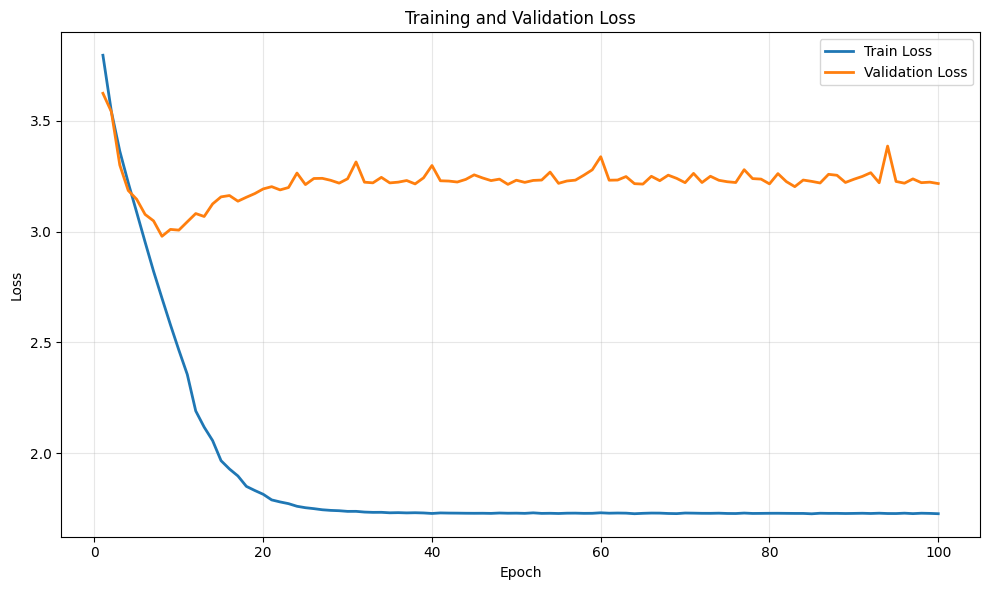

Saved : C:\LipReadingSSL\output\phase8_lipreading\results\training_graphs\loss_curve.png


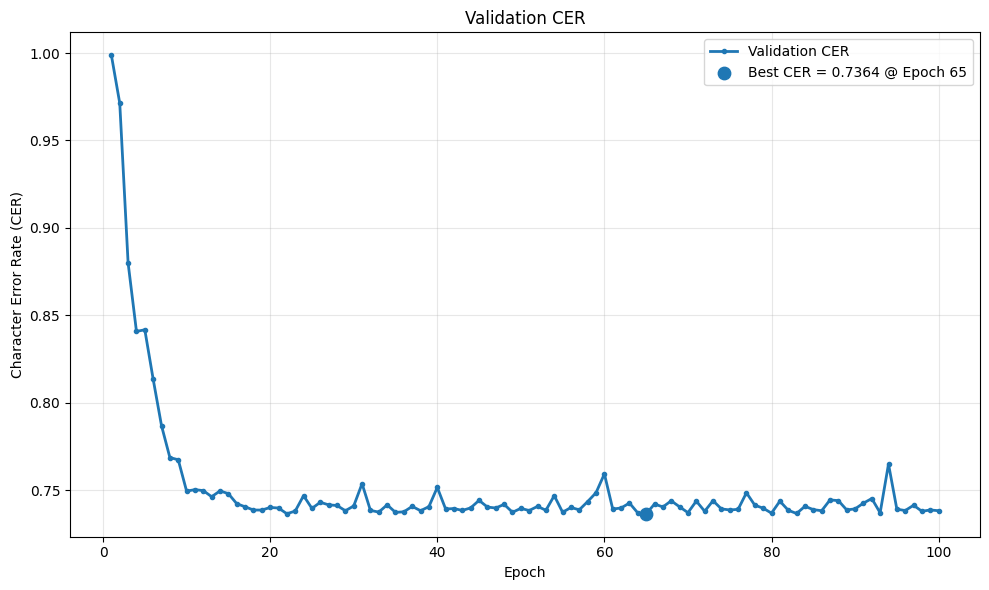

Saved : C:\LipReadingSSL\output\phase8_lipreading\results\training_graphs\validation_cer_curve.png


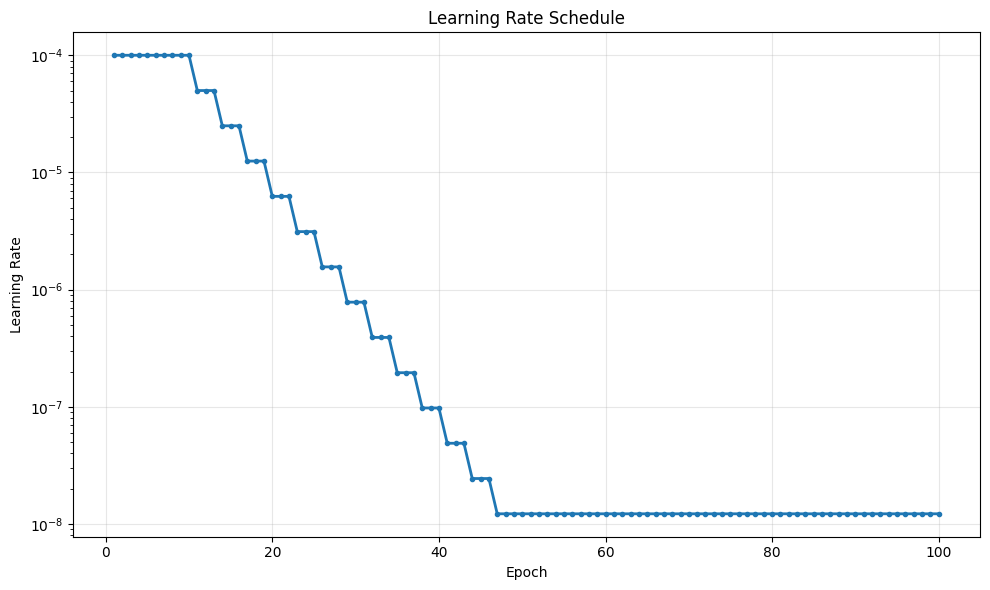

Saved : C:\LipReadingSSL\output\phase8_lipreading\results\training_graphs\learning_rate_curve.png


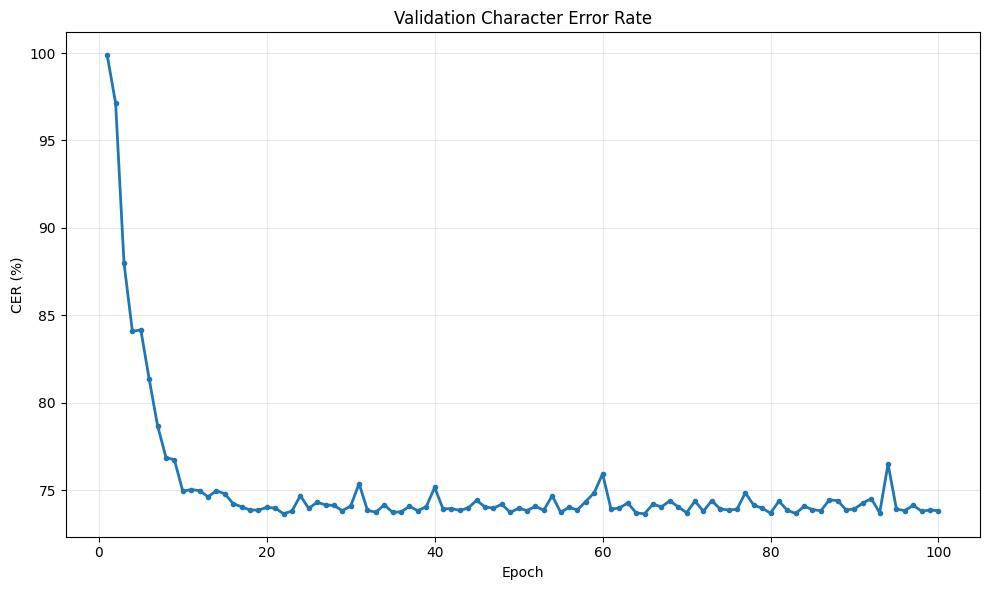

Saved : C:\LipReadingSSL\output\phase8_lipreading\results\training_graphs\validation_cer_percent.png

TRAINING GRAPH SUMMARY
Completed epochs : 100
Best epoch      : 65
Best Val CER    : 0.7364
Best Val Loss   : 3.2148

GRAPH FILES
----------------------------------------------------------------------------------------------------
Loss curve      : C:\LipReadingSSL\output\phase8_lipreading\results\training_graphs\loss_curve.png
CER curve       : C:\LipReadingSSL\output\phase8_lipreading\results\training_graphs\validation_cer_curve.png
Learning rate   : C:\LipReadingSSL\output\phase8_lipreading\results\training_graphs\learning_rate_curve.png
CER percentage   : C:\LipReadingSSL\output\phase8_lipreading\results\training_graphs\validation_cer_percent.png

Metrics summary : C:\LipReadingSSL\output\phase8_lipreading\results\training_graphs\training_metrics_summary.csv

TRAINING CURVES : COMPLETE


In [19]:
# ====================================================================================================
# PHASE 8 — CELL 15
# TRAINING CURVES / METRICS GRAPHS
# ====================================================================================================

print("=" * 100)
print("PHASE 8 — CELL 15 — TRAINING CURVES")
print("=" * 100)

# ----------------------------------------------------------------------------------------------------
# IMPORT
# ----------------------------------------------------------------------------------------------------

import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ----------------------------------------------------------------------------------------------------
# PATH
# ----------------------------------------------------------------------------------------------------

TRAINING_GRAPH_DIR = (
    RESULT_DIR
    / "training_graphs"
)

TRAINING_GRAPH_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ----------------------------------------------------------------------------------------------------
# CHECK HISTORY FILE
# ----------------------------------------------------------------------------------------------------

if not HISTORY_FILE.exists():

    raise FileNotFoundError(
        f"Training history not found:\n"
        f"{HISTORY_FILE}"
    )

# ----------------------------------------------------------------------------------------------------
# LOAD TRAINING HISTORY
# ----------------------------------------------------------------------------------------------------

history_df = pd.read_csv(
    HISTORY_FILE
)

# Remove duplicated epochs if any
history_df = (
    history_df
    .drop_duplicates(
        subset=["epoch"],
        keep="last"
    )
    .sort_values(
        "epoch"
    )
    .reset_index(drop=True)
)

print()
print(
    f"History loaded : {len(history_df)} epochs"
)

print(
    f"Epoch range    : "
    f"{history_df['epoch'].min()} - "
    f"{history_df['epoch'].max()}"
)

# ----------------------------------------------------------------------------------------------------
# GRAPH 1 — TRAIN LOSS vs VALIDATION LOSS
# ----------------------------------------------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss",
    linewidth=2
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Training and Validation Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

LOSS_GRAPH = (
    TRAINING_GRAPH_DIR
    / "loss_curve.png"
)

plt.savefig(
    LOSS_GRAPH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

plt.close()

print(
    f"Saved : {LOSS_GRAPH}"
)

# ----------------------------------------------------------------------------------------------------
# GRAPH 2 — VALIDATION CER
# ----------------------------------------------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["epoch"],
    history_df["val_cer"],
    marker="o",
    markersize=3,
    linewidth=2,
    label="Validation CER"
)

best_cer_index = (
    history_df["val_cer"]
    .idxmin()
)

best_cer_epoch = int(
    history_df.loc[
        best_cer_index,
        "epoch"
    ]
)

best_cer_value = float(
    history_df.loc[
        best_cer_index,
        "val_cer"
    ]
)

plt.scatter(
    best_cer_epoch,
    best_cer_value,
    s=80,
    label=(
        f"Best CER = {best_cer_value:.4f}"
        f" @ Epoch {best_cer_epoch}"
    )
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Character Error Rate (CER)"
)

plt.title(
    "Validation CER"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

CER_GRAPH = (
    TRAINING_GRAPH_DIR
    / "validation_cer_curve.png"
)

plt.savefig(
    CER_GRAPH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

plt.close()

print(
    f"Saved : {CER_GRAPH}"
)

# ----------------------------------------------------------------------------------------------------
# GRAPH 3 — LEARNING RATE
# ----------------------------------------------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["epoch"],
    history_df["learning_rate"],
    marker="o",
    markersize=3,
    linewidth=2
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Learning Rate"
)

plt.title(
    "Learning Rate Schedule"
)

plt.yscale(
    "log"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

LR_GRAPH = (
    TRAINING_GRAPH_DIR
    / "learning_rate_curve.png"
)

plt.savefig(
    LR_GRAPH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

plt.close()

print(
    f"Saved : {LR_GRAPH}"
)

# ----------------------------------------------------------------------------------------------------
# GRAPH 4 — NORMALIZED CER (%)
# ----------------------------------------------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["epoch"],
    history_df["val_cer"] * 100,
    marker="o",
    markersize=3,
    linewidth=2
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "CER (%)"
)

plt.title(
    "Validation Character Error Rate"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

CER_PERCENT_GRAPH = (
    TRAINING_GRAPH_DIR
    / "validation_cer_percent.png"
)

plt.savefig(
    CER_PERCENT_GRAPH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

plt.close()

print(
    f"Saved : {CER_PERCENT_GRAPH}"
)

# ----------------------------------------------------------------------------------------------------
# SAVE METRICS SUMMARY
# ----------------------------------------------------------------------------------------------------

best_epoch_row = history_df.loc[
    history_df["val_cer"].idxmin()
]

metrics_summary = {
    "best_epoch": int(
        best_epoch_row["epoch"]
    ),

    "best_val_cer": float(
        best_epoch_row["val_cer"]
    ),

    "best_val_loss": float(
        best_epoch_row["val_loss"]
    ),

    "train_loss_at_best_epoch": float(
        best_epoch_row["train_loss"]
    ),

    "learning_rate_at_best_epoch": float(
        best_epoch_row["learning_rate"]
    ),

    "total_completed_epochs": int(
        history_df["epoch"].max()
    ),
}

METRICS_SUMMARY_FILE = (
    TRAINING_GRAPH_DIR
    / "training_metrics_summary.csv"
)

pd.DataFrame(
    [metrics_summary]
).to_csv(
    METRICS_SUMMARY_FILE,
    index=False,
    encoding="utf-8-sig"
)

# ----------------------------------------------------------------------------------------------------
# FINAL OUTPUT
# ----------------------------------------------------------------------------------------------------

print()
print("=" * 100)
print("TRAINING GRAPH SUMMARY")
print("=" * 100)

print(
    f"Completed epochs : "
    f"{metrics_summary['total_completed_epochs']}"
)

print(
    f"Best epoch      : "
    f"{metrics_summary['best_epoch']}"
)

print(
    f"Best Val CER    : "
    f"{metrics_summary['best_val_cer']:.4f}"
)

print(
    f"Best Val Loss   : "
    f"{metrics_summary['best_val_loss']:.4f}"
)

print()
print("GRAPH FILES")
print("-" * 100)

print(
    f"Loss curve      : {LOSS_GRAPH}"
)

print(
    f"CER curve       : {CER_GRAPH}"
)

print(
    f"Learning rate   : {LR_GRAPH}"
)

print(
    f"CER percentage   : {CER_PERCENT_GRAPH}"
)

print()
print(
    f"Metrics summary : {METRICS_SUMMARY_FILE}"
)

print()
print("TRAINING CURVES : COMPLETE")